In [ ]:
#optimum with price constraint till the first decimal
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import time  # Import the time module for performance tracking


# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        """
        Initialize the optimizer.

        Parameters:
        - A_matrix: The power flow matrix.
        - line_limits: The line capacity limits.
        - memory_size: The size of the solution memory.
        - max_sum_diff: The maximum allowed sum of differences between original and optimized injections.
        """
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        self.algorithm_weights = {'OOA': 0.3, 'KHA': 0.3, 'SHO': 0.4}  # Initial algorithm weights
        self.adaptive_weights = True  # Control adaptive weights.
        self.generator_prices = None # Will store generator prices

    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using a hybrid of OOA, KHA, and SHO algorithms with memory.

        Parameters:
        - B: Original power injections.
        - iterations: Maximum number of iterations.
        - population_size: Size of the population.
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis).
        """
        start_time = time.time()  # Record the start time

        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size // 2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size // 2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population
        initial_population[0] = B.copy()

        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)

        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        algorithm_successes = {'OOA': 0, 'KHA': 0, 'SHO': 0}  # Track algorithm success
        stagnation_counter = 0
        previous_best_fitness = best_fitness

        # Main optimization loop
        for iteration in range(iterations):
            if self.adaptive_weights:
                self._update_algorithm_weights(algorithm_successes)  # Update weights adaptively

            new_population = []

            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Select algorithm based on adaptive weights
                algorithm = random.choices(list(self.algorithm_weights.keys()),
                                           weights=list(self.algorithm_weights.values()), k=1)[0]

                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration,
                                                                 iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                # Ensure power balance
                new_solution -= np.mean(new_solution)

                # Add to new population
                new_population.append(new_solution)

                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)

                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    algorithm_successes[algorithm] += 1  # Increment algorithm success counter

                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}, Best Fitness: {best_fitness:.6f}")
                else:
                    algorithm_successes[algorithm] *= 0.9  # Decay success if not improved

            # Replace old population with new population
            initial_population = new_population

            # Record fitness history
            fitness_history.append(best_fitness)

            # Check for stagnation and adapt algorithms if necessary
            if abs(best_fitness - previous_best_fitness) < 1e-6:
                stagnation_counter += 1
                if stagnation_counter >= 10:  # Increased stagnation threshold
                    print("Stagnation detected.  Re-initializing some solutions.")
                    # Re-initialize a portion of the population to increase diversity
                    for i in range(population_size // 4):  # Re-initialize 25% of population
                        initial_population[random.randint(0, population_size - 1)] = self._generate_random_solution(B)
                    stagnation_counter = 0  # Reset counter
            else:
                stagnation_counter = 0
            previous_best_fitness = best_fitness

            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break

        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)

        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)

        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)

        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count / total * 100:.1f}%")

        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")

        end_time = time.time()  # Record the end time
        print(f"Optimization time: {end_time - start_time:.2f} seconds")

        return best_solution, fitness_history, np.dot(self.A, best_solution)

    def _update_algorithm_weights(self, algorithm_successes):
        """
        Dynamically update algorithm weights based on their recent success.
        """
        total_success = sum(algorithm_successes.values())
        if total_success > 0:
            for algo in self.algorithm_weights:
                # Update weight based on success rate, with a smoothing factor
                self.algorithm_weights[algo] = 0.8 * self.algorithm_weights[algo] + 0.2 * (
                        algorithm_successes[algo] / total_success)
        else:
            # If no success, keep weights as they are
            pass

        # Normalize weights to sum to 1
        total_weight = sum(self.algorithm_weights.values())
        for algo in self.algorithm_weights:
            self.algorithm_weights[algo] /= total_weight

    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint.

        Parameters:
        - solution: The current solution.
        - original_B: The original power injections.
        - steps: Number of steps to take in the minimization process.
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)

        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)

            # Ensure power balance
            new_solution -= np.mean(new_solution)

            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")

        return best_solution

    def _generate_random_solution(self, B):
        """
        Generate a random solution based on the original B that respects the sum diff constraint.

        Parameters:
        - B: The original power injections.
        """
        max_attempts = 10

        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean()
            random_solution -= np.mean(random_solution)  # Ensure power balance

            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution

        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint.

        Parameters:
        - solution: Current solution to evaluate.
        - original_B: Original power injections.
        - alpha: Weight for minimizing changes (higher = more emphasis).
        """
        C = np.dot(self.A, solution)

        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, np.abs(C.flatten()) - self.line_limits))

        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)

        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10

        # Calculate rescheduling cost.  Make sure generator_prices is not None
        if self.generator_prices is not None:
            rescheduling_cost = np.sum(self.generator_prices * np.abs(solution - original_B))
        else:
            rescheduling_cost = 0

        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty + rescheduling_cost

    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)."""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        # Round to 1 decimal place for comparison
        C_rounded = np.round(np.abs(C.flatten()), 1)
        line_limits_rounded = np.round(self.line_limits, 1)
        line_constraints_met = np.all(C_rounded <= line_limits_rounded)

        return line_constraints_met

    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution."""
        if not self.memory:
            return None

        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')

        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)

            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))

            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B

        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory."""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy."""
        solution = population[index].copy()

        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()

        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]

        # Binary success indicator (simplified)
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution,
                                                                                          solution) else 0

        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)

            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)

        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy."""
        solution = population[index].copy()

        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5  # Inertia weight
        c_best = 2  # Best krill effect
        c_rand = 1  # Random krill effect

        # Motion induction (other krill effect)
        N_old = 0  # Previous motion
        neighbors = random.sample(population, min(3, len(population) - 1))

        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)

        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)

        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()

        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)

        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D

        return new_solution

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy."""
        solution = population[index].copy()

        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0

        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index],
                                       min(3, len(population) - 1))
        random_solutions = [population[i] for i in random_indices]

        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)

        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha

            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2

        return new_solution


# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0, generator_prices=None):
    """
    Optimize power flow using the HybridPowerFlowOptimizer.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - iterations: The maximum number of iterations.
    - alpha: The weighting factor for minimizing changes.
    - max_sum_diff: Maximum allowed sum of differences.
    - generator_prices: List/array of generator prices ($/MWh).
    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    """
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    if generator_prices is not None:
        optimizer.generator_prices = generator_prices

    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)

    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)

    return B_optimized, fitness_history, C_optimized, C_unoptimized


# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0,
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001, generator_prices=None):
    """
    Incrementally find the minimum sufficient sum_diff that leads to a feasible solution.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - alpha: Weighting factor.
    - start_sum_diff: Starting sum difference.
    - step_size: Initial step size.
    - max_attempts: Maximum number of attempts.
    - min_step_size: Minimum step size allowed.
    - generator_prices: List/array of generator prices ($/MWh).

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    - best_feasible_sum_diff: The minimum sum difference found.
    """
    print("Starting incremental search for minimum sum difference...")

    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')

    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(np.round(np.abs(C_unoptimized.flatten()), 1) <= np.round(line_limits, 1)):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0

    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")

    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None

    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")

        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            if generator_prices is not None:
                optimizer.generator_prices = generator_prices
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=150, alpha=alpha)

            # Check if constraints are satisfied
            is_feasible = np.all(np.round(np.abs(C_optimized.flatten()), 1) <= np.round(line_limits, 1))

            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))

            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")

                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff

                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.8f}")

                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(f"Switching to binary search between {last_failing_sum_diff:.8f} and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff

                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")

                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                            if generator_prices is not None:
                                optimizer.generator_prices = generator_prices
                            B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=150, alpha=alpha)

                            if np.all(np.round(np.abs(C_opt.flatten()), 1) <= np.round(line_limits, 1)):
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")

                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")

                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")

                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff

                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff

                # Reduce step size for more precise search.  Important for fine tuning.
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5) # Subtract a few steps worth
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")

            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")

                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff

                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size

        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size

    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)  # Try with a large value
        if generator_prices is not None:
                optimizer.generator_prices = generator_prices
        B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0

    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff



# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    """
    Visualize and report the results of the power flow optimization.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - B_optimized: The optimized power injections.
    - C_optimized: The optimized line flows.
    - C_unoptimized: The unoptimized line flows.
    - line_limits: The line capacity limits.
    - fitness_history: The history of fitness values during optimization.
    - max_sum_diff: The maximum allowed sum of differences.
    """
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b',
                 label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i + 0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7,
            color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)

    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized- B) / np.linalg.norm(B) * 100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")

    # Check that constraints are satisfied
    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(
        f"Percentage Difference: {(np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized))) / np.sum(abs(C_unoptimized)) * 100:.6f }%")



# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
        [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
        [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
        [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for generator prices
    num_generators = 5  # Assuming 5 generators based on the B matrix size
    generator_prices = []
    for i in range(num_generators):
        price = float(input(f"Enter price ($/MWh) for generator {i + 1}: "))
        generator_prices.append(price)
    generator_prices = np.array(generator_prices)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                      line_limits,
                                                                                                      alpha=alpha, generator_prices=generator_prices)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      fitness_history, max_sum_diff=optimal_sum_diff)

    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")

            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")

            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i + 1}: {limit}\n")

            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

             # Write Generator Prices to the file
            f.write("\nGenerator Prices ($/MWh):\n")
            for i, price in enumerate(generator_prices):
                f.write(f"Generator {i + 1}: {price:.2f}\n")

            # Check for violations
            violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(
                        f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")

            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")

            print(f"Results saved to {filename}")

    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        # The main() function was removed to avoid recursion issues.  Here we just re-execute the main logic.
        if __name__ == "__main__":
            # Define the given 7x5 matrix (Power Flow Coefficients)
            A = np.array([
                [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
                [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
                [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
                [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
                [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
                [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
                [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
            ])

            # User input for Line Power Limits (7 lines)
            print("Enter power limits for each line:")
            line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

            # User input for Bus Injection Matrix B (5x1)
            print("\nEnter power injections for each bus:")
            B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

             # User input for generator prices
            num_generators = 5  # Assuming 5 generators based on the B matrix size
            generator_prices = []
            for i in range(num_generators):
                price = float(input(f"Enter price ($/MWh) for generator {i + 1}: "))
                generator_prices.append(price)
            generator_prices = np.array(generator_prices)

            # User input for weighting factor (how much to prioritize minimal changes)
            alpha = float(input(
                "\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

            # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
            print("\nStarting incremental optimization to find minimum required sum of differences...")
            B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                              line_limits,
                                                                                                              alpha=alpha, generator_prices=generator_prices)
            print("\nVisualization of optimization results with minimum required sum of differences...")
            visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                              fitness_history, max_sum_diff=optimal_sum_diff)

            print("\nOptimization complete!")
            print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

            # Ask user if they want to save the results
            save_results = input("\nDo you want to save the results to a file? (y/n): ")
            if save_results.lower() == 'n':
                print("\nThank you for using the Hybrid Power Flow Optimizer!")
            else:
                print("\nRestarting program...\n")
    else:
        print("\nThank you for using the Hybrid Power Flow Optimizer!")


Enter power limits for each line:


Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50



Enter power injections for each bus:


Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45

Enter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9):  1



Starting incremental optimization to find minimum required sum of differences...
Starting incremental search for minimum sum difference...
Using adaptive step size: 0.00696000

Attempt 1: Testing max_sum_diff = 0.00000000
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected. 

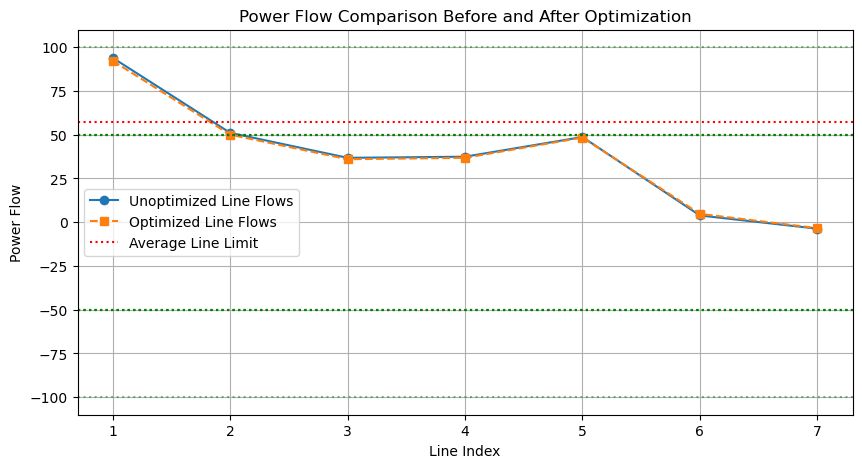

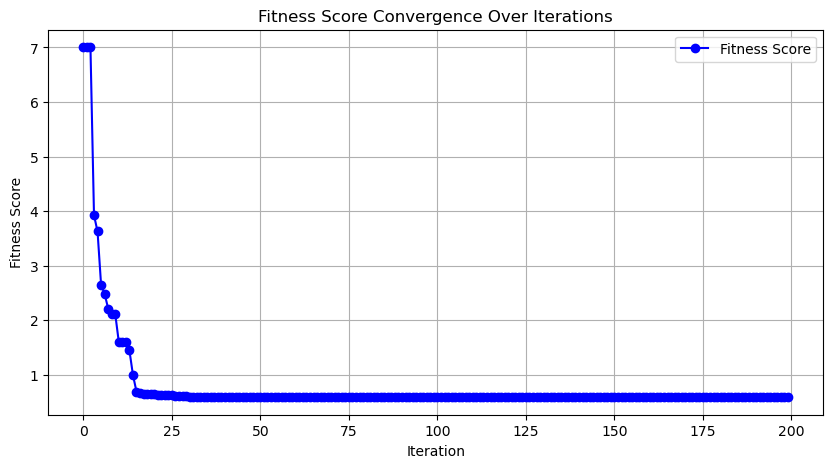

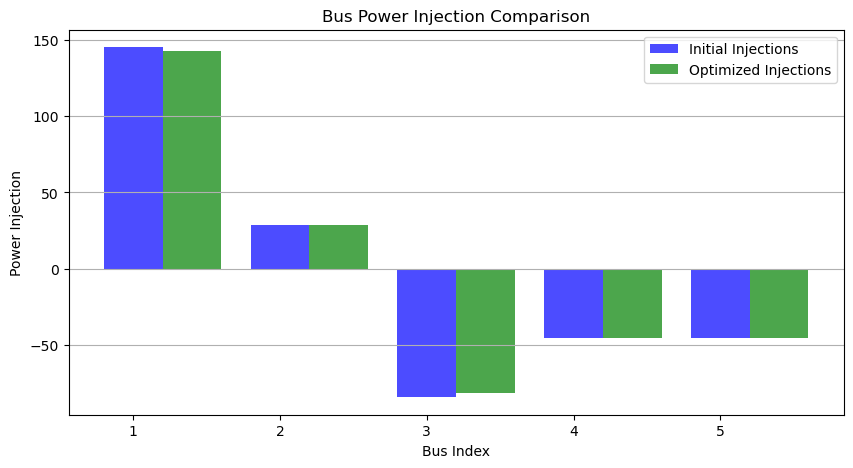

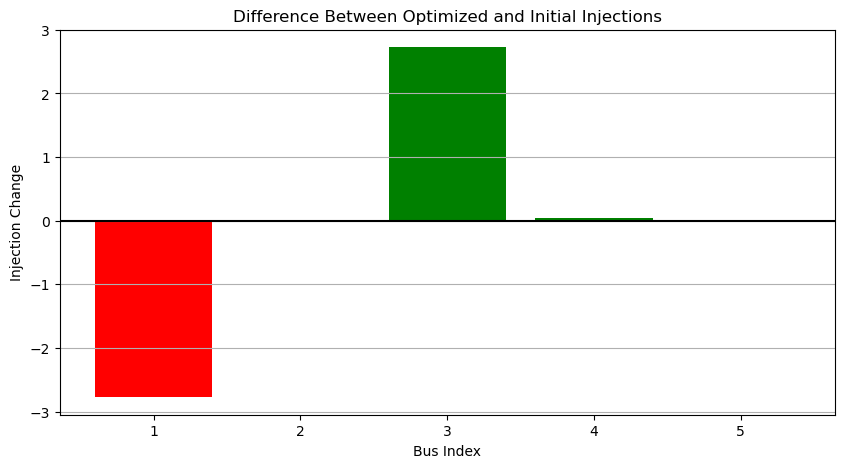


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[142.22576424]
 [ 28.99999997]
 [-81.27285808]
 [-44.95290612]
 [-45.00000001]]

Sum of Optimized Power Injections (Should be 0):  -7.105427357601002e-15

Resultant Line Flows After Optimization (7x1):
 [[92.17667251]
 [50.04909174]
 [36.00729062]
 [36.79852114]
 [48.371588  ]
 [ 4.7738017 ]
 [-3.37158799]]

Changes to Power Injections:
Absolute Changes: [2.77423576e+00 3.41948621e-08 2.72714192e+00 4.70938762e-02
 1.013

In [ ]:
#optimum without price constraint  till the first drcimal
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import time  # Import the time module for performance tracking


# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        """
        Initialize the optimizer.

        Parameters:
        - A_matrix: The power flow matrix.
        - line_limits: The line capacity limits.
        - memory_size: The size of the solution memory.
        - max_sum_diff: The maximum allowed sum of differences between original and optimized injections.
        """
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        self.algorithm_weights = {'OOA': 0.3, 'KHA': 0.3, 'SHO': 0.4}  # Initial algorithm weights
        self.adaptive_weights = True  # Control adaptive weights.

    def optimize(self, B, iterations=150, population_size=50, alpha=0.7):
        """
        Optimize power flow using a hybrid of OOA, KHA, and SHO algorithms with memory.

        Parameters:
        - B: Original power injections.
        - iterations: Maximum number of iterations.
        - population_size: Size of the population.
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis).
        """
        start_time = time.time()  # Record the start time

        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size // 2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size // 2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population
        initial_population[0] = B.copy()

        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)

        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        algorithm_successes = {'OOA': 0, 'KHA': 0, 'SHO': 0}  # Track algorithm success
        stagnation_counter = 0
        previous_best_fitness = best_fitness

        # Main optimization loop
        for iteration in range(iterations):
            if self.adaptive_weights:
                self._update_algorithm_weights(algorithm_successes)  # Update weights adaptively

            new_population = []

            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Select algorithm based on adaptive weights
                algorithm = random.choices(list(self.algorithm_weights.keys()),
                                           weights=list(self.algorithm_weights.values()), k=1)[0]

                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration,
                                                                 iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                # Ensure power balance
                new_solution -= np.mean(new_solution)

                # Add to new population
                new_population.append(new_solution)

                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)

                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    algorithm_successes[algorithm] += 1  # Increment algorithm success counter

                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}, Best Fitness: {best_fitness:.6f}")
                else:
                    algorithm_successes[algorithm] *= 0.9  # Decay success if not improved

            # Replace old population with new population
            initial_population = new_population

            # Record fitness history
            fitness_history.append(best_fitness)

            # Check for stagnation and adapt algorithms if necessary
            if abs(best_fitness - previous_best_fitness) < 1e-6:
                stagnation_counter += 1
                if stagnation_counter >= 10:  # Increased stagnation threshold
                    print("Stagnation detected.  Re-initializing some solutions.")
                    # Re-initialize a portion of the population to increase diversity
                    for i in range(population_size // 4):  # Re-initialize 25% of population
                        initial_population[random.randint(0, population_size - 1)] = self._generate_random_solution(B)
                    stagnation_counter = 0  # Reset counter
            else:
                stagnation_counter = 0
            previous_best_fitness = best_fitness

            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.01 and sum_diff <= self.max_sum_diff:
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break

        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)

        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)

        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)

        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count / total * 100:.1f}%")

        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")

        end_time = time.time()  # Record the end time
        print(f"Optimization time: {end_time - start_time:.2f} seconds")

        return best_solution, fitness_history, np.dot(self.A, best_solution)

    def _update_algorithm_weights(self, algorithm_successes):
        """
        Dynamically update algorithm weights based on their recent success.
        """
        total_success = sum(algorithm_successes.values())
        if total_success > 0:
            for algo in self.algorithm_weights:
                # Update weight based on success rate, with a smoothing factor
                self.algorithm_weights[algo] = 0.8 * self.algorithm_weights[algo] + 0.2 * (
                        algorithm_successes[algo] / total_success)
        else:
            # If no success, keep weights as they are
            pass

        # Normalize weights to sum to 1
        total_weight = sum(self.algorithm_weights.values())
        for algo in self.algorithm_weights:
            self.algorithm_weights[algo] /= total_weight

    def _minimize_changes(self, solution, original_B, steps=20):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint.

        Parameters:
        - solution: The current solution.
        - original_B: The original power injections.
        - steps: Number of steps to take in the minimization process.
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)

        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)

            # Ensure power balance
            new_solution -= np.mean(new_solution)

            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")

        return best_solution

    def _generate_random_solution(self, B):
        """
        Generate a random solution based on the original B that respects the sum diff constraint.

        Parameters:
        - B: The original power injections.
        """
        max_attempts = 20

        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean()
            random_solution -= np.mean(random_solution)  # Ensure power balance

            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution

        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint.

        Parameters:
        - solution: Current solution to evaluate.
        - original_B: Original power injections.
        - alpha: Weight for minimizing changes (higher = more emphasis).
        """
        C = np.dot(self.A, solution)

        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, np.abs(C.flatten()) - self.line_limits))

        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)

        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10

        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty

    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)."""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        # Round to 1 decimal place for comparison
        C_rounded = np.round(np.abs(C.flatten()), 1)
        line_limits_rounded = np.round(self.line_limits, 1)
        line_constraints_met = np.all(C_rounded <= line_limits_rounded)

        return line_constraints_met

    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution."""
        if not self.memory:
            return None

        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')

        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)

            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))

            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B

        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory."""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy."""
        solution = population[index].copy()

        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()

        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]

        # Binary success indicator (simplified)
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution,
                                                                                          solution) else 0

        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)

            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)

        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy."""
        solution = population[index].copy()

        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5  # Inertia weight
        c_best = 2  # Best krill effect
        c_rand = 1  # Random krill effect

        # Motion induction (other krill effect)
        N_old = 0  # Previous motion
        neighbors = random.sample(population, min(3, len(population) - 1))

        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)

        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)

        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()

        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)

        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D

        return new_solution

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy."""
        solution = population[index].copy()

        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0

        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index],
                                       min(3, len(population) - 1))
        random_solutions = [population[i] for i in random_indices]

        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)

        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha

            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2

        return new_solution


# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    """
    Optimize power flow using the HybridPowerFlowOptimizer.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - iterations: The maximum number of iterations.
    - alpha: The weighting factor for minimizing changes.
    - max_sum_diff: Maximum allowed sum of differences.

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    """
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)

    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)

    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)

    return B_optimized, fitness_history, C_optimized, C_unoptimized


# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.00,
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001):
    """
    Incrementally find the minimum sufficient sum_diff that leads to a feasible solution.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - alpha: Weighting factor.
    - start_sum_diff: Starting sum difference.
    - step_size: Initial step size.
    - max_attempts: Maximum number of attempts.
    - min_step_size: Minimum step size allowed.

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    - best_feasible_sum_diff: The minimum sum difference found.
    """
    print("Starting incremental search for minimum sum difference...")

    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')

    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(np.round(np.abs(C_unoptimized.flatten()), 1) <= np.round(line_limits, 1)):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0

    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")

    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None

    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")

        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)

            # Check if constraints are satisfied
            is_feasible = np.all(np.round(np.abs(C_optimized.flatten()), 1) <= np.round(line_limits, 1))

            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))

            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")

                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff

                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.8f}")

                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(
                            f"Switching to binary search between {last_failing_sum_diff:.8f} and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff

                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")

                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                            B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=200, alpha=alpha)

                            if np.all(np.round(np.abs(C_opt.flatten()), 1) <= np.round(line_limits, 1)):
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")

                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")

                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")

                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff

                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff

                # Reduce step size for more precise search.  Important for fine tuning.
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5) # Subtract a few steps worth
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")

            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")

                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff

                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size

        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size

    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)  # Try with a large value
        B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0

    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff



# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    """
    Visualize and report the results of the power flow optimization.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - B_optimized: The optimized power injections.
    - C_optimized: The optimized line flows.
    - C_unoptimized: The unoptimized line flows.
    - line_limits: The line capacity limits.
    - fitness_history: The history of fitness values during optimization.
    - max_sum_diff: The maximum allowed sum of differences.
    """
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b',
                 label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i + 0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7,
            color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)

    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B) / np.linalg.norm(B) * 100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")

    # Check that constraints are satisfied
    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {(np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized))) / np.sum(abs(C_unoptimized)) * 100:.6f}%")



# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
        [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
        [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
        [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                      line_limits,
                                                                                                      alpha=alpha)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      fitness_history, max_sum_diff=optimal_sum_diff)

    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")

            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")

            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i + 1}: {limit}\n")

            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

            # Check for violations
            violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(
                        f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")

            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")

            print(f"Results saved to {filename}")

    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        # The main() function was removed to avoid recursion issues.  Here we just re-execute the main logic.
        if __name__ == "__main__":
            # Define the given 7x5 matrix (Power Flow Coefficients)
            A = np.array([
                [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
                [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
                [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
                [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
                [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
                [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
                [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
            ])

            # User input for Line Power Limits (7 lines)
            print("Enter power limits for each line:")
            line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

            # User input for Bus Injection Matrix B (5x1)
            print("\nEnter power injections for each bus:")
            B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

            # User input for weighting factor (how much to prioritize minimal changes)
            alpha = float(input(
                "\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

            # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
            print("\nStarting incremental optimization to find minimum required sum of differences...")
            B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                              line_limits,
                                                                                                              alpha=alpha)
            print("\nVisualization of optimization results with minimum required sum of differences...")
            visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                              fitness_history, max_sum_diff=optimal_sum_diff)

            print("\nOptimization complete!")
            print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

            # Ask user if they want to save the results
            save_results = input("\nDo you want to save the results to a file? (y/n): ")
            if save_results.lower() == 'y':
                filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

                with open(filename, 'w') as f:
                    f.write("Power Flow Optimization Results\n")
                    f.write("==============================\n\n")

                    f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
                    for row in A:
                        f.write(str(row) + "\n")

                    f.write("\nLine Power Limits:\n")
                    for i, limit in enumerate(line_limits):
                        f.write(f"Line {i + 1}: {limit}\n")

                    f.write("\nInitial Power Injections (B, 5x1):\n")
                    for i, injection in enumerate(B):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
                    for i, injection in enumerate(B_optimized):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
                    for i, flow in enumerate(C_unoptimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
                    for i, flow in enumerate(C_optimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

                    # Check for violations
                    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
                    if len(violations) > 0:
                        f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                        for line in violations:
                            f.write(
                                f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
                    else:
                        f.write("\nAll line constraints satisfied!\n")

                    f.write("\nOptimization Parameters:\n")
                    f.write(f"Alpha (weight for minimal changes): {alpha}\n")

                    print(f"Results saved to {filename}")
            run_again = input("\nDo you want to run another scenario? (y/n): ")
            if run_again.lower() == 'n':
                print("\nThank you for using the Hybrid Power Flow Optimizer!")
            else:
                print("\nRestarting program...\n")
    else:
        print("\nThank you for using the Hybrid Power Flow Optimizer!")


Enter power limits for each line:


Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50



Enter power injections for each bus:


Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45

Enter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9):  1



Starting incremental optimization to find minimum required sum of differences...
Starting incremental search for minimum sum difference...
Using adaptive step size: 0.00696000

Attempt 1: Testing max_sum_diff = 0.00000000

Algorithm Contributions:
OOA: 35.9%
KHA: 36.0%
SHO: 28.0%

Final sum of differences: 0.000000 (max allowed: 0.00000000)
✗ INFEASIBLE solution with sum_diff = 0.00000000

Attempt 2: Testing max_sum_diff = 0.00696000

Algorithm Contributions:
OOA: 36.8%
KHA: 35.0%
SHO: 28.2%

Final sum of differences: 0.006955 (max allowed: 0.00696000)
✗ INFEASIBLE solution with sum_diff = 0.00696000

Attempt 3: Testing max_sum_diff = 0.01392000

Algorithm Contributions:
OOA: 35.7%
KHA: 36.6%
SHO: 27.7%

Final sum of differences: 0.013828 (max allowed: 0.01392000)
✗ INFEASIBLE solution with sum_diff = 0.01392000

Attempt 4: Testing max_sum_diff = 0.02088000

Algorithm Contributions:
OOA: 36.3%
KHA: 35.8%
SHO: 27.8%

Final sum of differences: 0.020879 (max allowed: 0.02088000)
✗ INFEAS

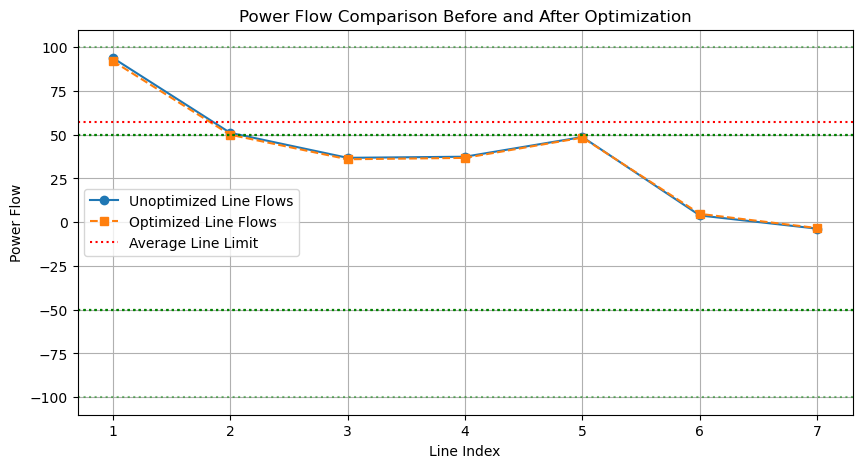

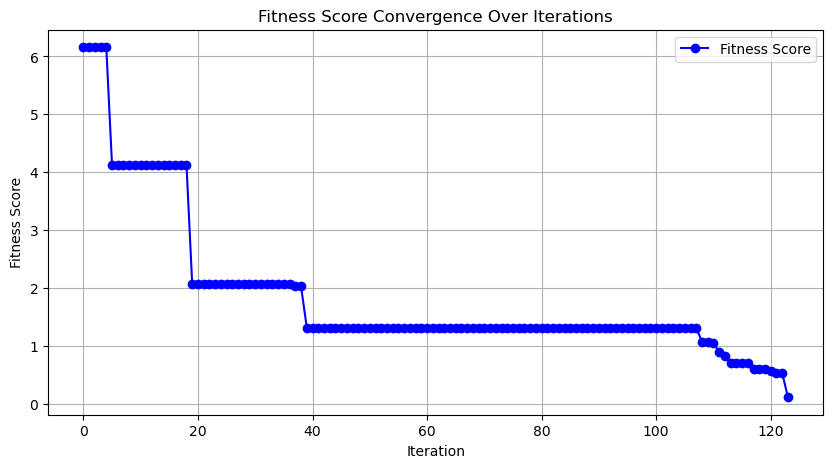

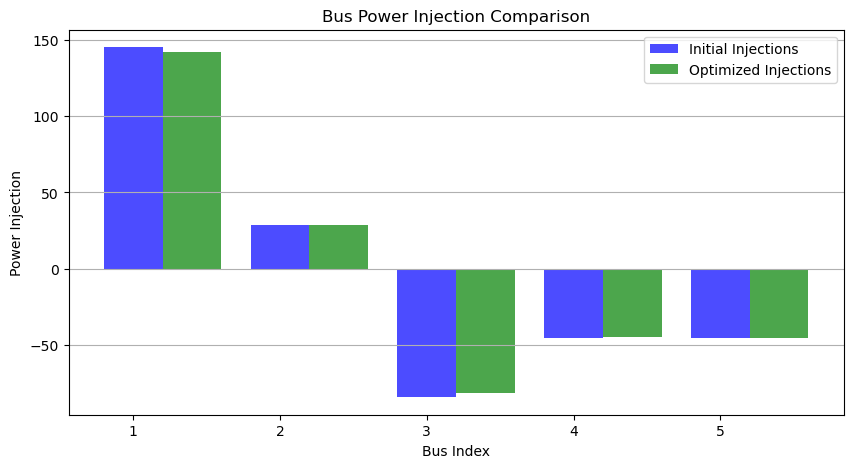

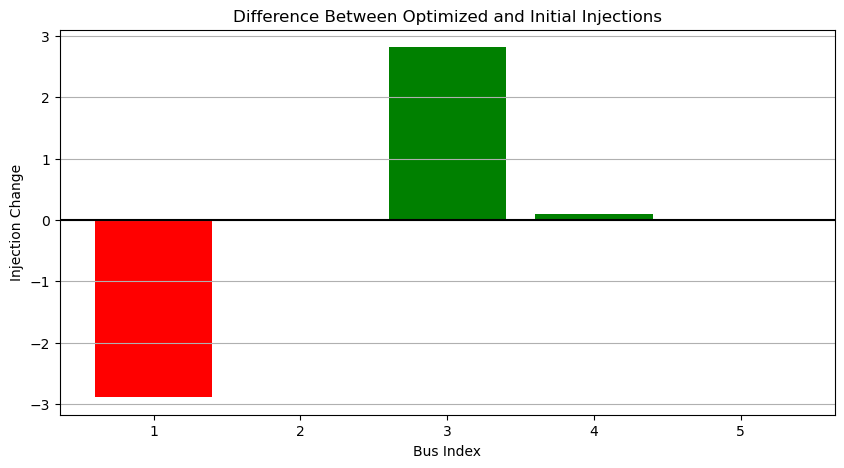


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[142.11251175]
 [ 28.97719166]
 [-81.18590272]
 [-44.90809697]
 [-44.99570372]]

Sum of Optimized Power Injections (Should be 0):  -1.4210854715202004e-14

Resultant Line Flows After Optimization (7x1):
 [[92.10778345]
 [50.0047283 ]
 [35.97110498]
 [36.76340972]
 [48.35118171]
 [ 4.78021888]
 [-3.35547799]]

Changes to Power Injections:
Absolute Changes: [2.88748825 0.02280834 2.81409728 0.09190303 0.00429628]
Sum of Ab

In [ ]:
#optimum till the 2nd decimal without price
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        
    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory
        
        Parameters:
        - B: Original power injections
        - iterations: Maximum number of iterations
        - population_size: Size of the population
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis)
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]
        
        # Ensure the original B is in the population
        initial_population[0] = B.copy()
        
        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)
        
        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        
        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant
            
            new_population = []
            
            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                
                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1
                
                # Ensure power balance
                new_solution -= np.mean(new_solution)
                
                # Add to new population
                new_population.append(new_solution)
                
                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)
                
                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    
                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}")
            
            # Replace old population with new population
            initial_population = new_population
            
            # Record fitness history
            fitness_history.append(best_fitness)
            
            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal and below sum difference threshold
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:  
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break
        
        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)
        
        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)
        
        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)
        
        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count/total*100:.1f}%")
        
        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
        
        return best_solution, fitness_history, np.dot(self.A, best_solution)
    
    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)
        
        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)
            
            # Ensure power balance
            new_solution -= np.mean(new_solution)
            
            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")
        
        return best_solution
    
    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B that respects sum diff constraint"""
        max_attempts = 10
        
        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean() 
            random_solution -= np.mean(random_solution)  # Ensure power balance
            
            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution
        
        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution
    
    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint
        
        Parameters:
        - solution: Current solution to evaluate
        - original_B: Original power injections
        - alpha: Weight for minimizing changes (higher = more emphasis)
        """
        C = np.dot(self.A, solution)
        
        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, abs(C.flatten()) - self.line_limits))
        
        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)
        
        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10
        
        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty
    
    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)"""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        # Round the line flows to two decimal places for comparison
        rounded_C = np.round(C.flatten(), 2)
        rounded_limits = np.round(self.line_limits, 2)
        line_constraints_met = np.all(abs(rounded_C) <= rounded_limits)
        
        return line_constraints_met
    
    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None
        
        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')
        
        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)
            
            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))
            
            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B
        
        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None
    
    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")
    
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()
        
        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]
        
        # Binary success indicator
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution, solution) else 0
        
        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)
            
            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)
        
        return new_solution
    
    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5   # Inertia weight
        c_best = 2    # Best krill effect
        c_rand = 1    # Random krill effect
        
        # Motion induction (other krill effect)
        N_old = 0     # Previous motion
        neighbors = random.sample(population, min(3, len(population)-1))
        
        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)
        
        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)
        
        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()
        
        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)
        
        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D
        
        return new_solution
    
    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()
        
        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0
        
        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index], 
                                       min(3, len(population)-1))
        random_solutions = [population[i] for i in random_indices]
        
        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)
        
        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha
            
            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2
        
        return new_solution

# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)
    
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)
    
    return B_optimized, fitness_history, C_optimized, C_unoptimized

# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0, 
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001):
    print("Starting incremental search for minimum sum difference...")
    
    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')
    
    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    
    # Round the initial power flows and line limits to two decimals for comparison
    rounded_C_unoptimized = np.round(C_unoptimized.flatten(), 2)
    rounded_line_limits = np.round(line_limits, 2)
    
    if np.all(abs(rounded_C_unoptimized) <= rounded_line_limits):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0
    
    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")
    
    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None
    
    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")
        
        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=150, alpha=alpha)
            
            # Check if constraints are satisfied
            #is_feasible = np.all(abs(C_optimized.flatten()) <= line_limits)
            is_feasible = optimizer._is_feasible(B_optimized) # Use the is_feasible method
            
            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))
            
            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")
                
                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff
                    
                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.8f}")
                    
                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(f"Switching to binary search between {last_failing_sum_diff:.8f} and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff
                        
                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")
                            
                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                            B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=150, alpha=alpha)
                            
                            #if np.all(abs(C_opt.flatten()) <= line_limits):
                            if optimizer._is_feasible(B_opt): # Use the is_feasible method
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")
                                
                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")
                        
                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")
                        
                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff
                
                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff
                
                # Reduce step size for more precise search
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5)
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")
                
            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")
                
                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff
                
                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size
        
        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size
    
    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)  # Try with a large value
        B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0
    
    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b', label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i+0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)
    
    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B)/np.linalg.norm(B)*100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")
    
    # Check that constraints are satisfied
    violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {((np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)))/np.sum(abs(C_unoptimized)))*100:.6f}%")

# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i+1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))
    
    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B, line_limits, alpha=alpha)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, 
                     fitness_history, max_sum_diff=optimal_sum_diff)
    
    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")
    
    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"
        
        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")
            
            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")
            
            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i+1}: {limit}\n")
            
            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i+1}: {injection[0]}\n")
            
            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i+1}: {injection[0]}\n")
            
            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i+1}: {flow[0]}\n")
            
            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i+1}: {flow[0]}\n")
            
            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")
            
            # Check for violations
            violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")
            
            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")
            
            print(f"Results saved to {filename}")
    
    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        print("\nRestarting program...\n")
        main()  # This will cause an error since main() is not defined
    else:
        print("\nThank you for using the Hybrid Power Flow Optimizer!")



In [3]:
#optimum without price constraint  till the first drcimal
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import time  # Import the time module for performance tracking


# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        """
        Initialize the optimizer.

        Parameters:
        - A_matrix: The power flow matrix.
        - line_limits: The line capacity limits.
        - memory_size: The size of the solution memory.
        - max_sum_diff: The maximum allowed sum of differences between original and optimized injections.
        """
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        self.algorithm_weights = {'OOA': 0.3, 'KHA': 0.3, 'SHO': 0.4}  # Initial algorithm weights
        self.adaptive_weights = True  # Control adaptive weights.
        self.generator_costs = {} # Dictionary to store generator costs

    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using a hybrid of OOA, KHA, and SHO algorithms with memory.

        Parameters:
        - B: Original power injections.
        - iterations: Maximum number of iterations.
        - population_size: Size of the population.
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis).
        """
        start_time = time.time()  # Record the start time

        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size // 2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size // 2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population
        initial_population[0] = B.copy()

        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)

        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        algorithm_successes = {'OOA': 0, 'KHA': 0, 'SHO': 0}  # Track algorithm success
        stagnation_counter = 0
        previous_best_fitness = best_fitness

        # Main optimization loop
        for iteration in range(iterations):
            if self.adaptive_weights:
                self._update_algorithm_weights(algorithm_successes)  # Update weights adaptively

            new_population = []

            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Select algorithm based on adaptive weights
                algorithm = random.choices(list(self.algorithm_weights.keys()),
                                           weights=list(self.algorithm_weights.values()), k=1)[0]

                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration,
                                                                 iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                # Ensure power balance
                new_solution -= np.mean(new_solution)

                # Add to new population
                new_population.append(new_solution)

                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)

                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    algorithm_successes[algorithm] += 1  # Increment algorithm success counter

                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}, Best Fitness: {best_fitness:.6f}")
                else:
                    algorithm_successes[algorithm] *= 0.9  # Decay success if not improved

            # Replace old population with new population
            initial_population = new_population

            # Record fitness history
            fitness_history.append(best_fitness)

            # Check for stagnation and adapt algorithms if necessary
            if abs(best_fitness - previous_best_fitness) < 1e-6:
                stagnation_counter += 1
                if stagnation_counter >= 10:  # Increased stagnation threshold
                    print("Stagnation detected.  Re-initializing some solutions.")
                    # Re-initialize a portion of the population to increase diversity
                    for i in range(population_size // 4):  # Re-initialize 25% of population
                        initial_population[random.randint(0, population_size - 1)] = self._generate_random_solution(B)
                    stagnation_counter = 0  # Reset counter
            else:
                stagnation_counter = 0
            previous_best_fitness = best_fitness

            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break

        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)

        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)

        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)

        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count / total * 100:.1f}%")

        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")

        end_time = time.time()  # Record the end time
        print(f"Optimization time: {end_time - start_time:.2f} seconds")

        return best_solution, fitness_history, np.dot(self.A, best_solution)

    def _update_algorithm_weights(self, algorithm_successes):
        """
        Dynamically update algorithm weights based on their recent success.
        """
        total_success = sum(algorithm_successes.values())
        if total_success > 0:
            for algo in self.algorithm_weights:
                # Update weight based on success rate, with a smoothing factor
                self.algorithm_weights[algo] = 0.8 * self.algorithm_weights[algo] + 0.2 * (
                        algorithm_successes[algo] / total_success)
        else:
            # If no success, keep weights as they are
            pass

        # Normalize weights to sum to 1
        total_weight = sum(self.algorithm_weights.values())
        for algo in self.algorithm_weights:
            self.algorithm_weights[algo] /= total_weight

    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint.

        Parameters:
        - solution: The current solution.
        - original_B: The original power injections.
        - steps: Number of steps to take in the minimization process.
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)

        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)

            # Ensure power balance
            new_solution -= np.mean(new_solution)

            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")

        return best_solution

    def _generate_random_solution(self, B):
        """
        Generate a random solution based on the original B that respects the sum diff constraint.

        Parameters:
        - B: The original power injections.
        """
        max_attempts = 10

        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean()
            random_solution -= np.mean(random_solution)  # Ensure power balance

            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution

        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint.

        Parameters:
        - solution: Current solution to evaluate.
        - original_B: Original power injections.
        - alpha: Weight for minimizing changes (higher = more emphasis).
        """
        C = np.dot(self.A, solution)

        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, np.abs(C.flatten()) - self.line_limits))

        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)

        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10

        # Calculate rescheduling cost using generator costs
        rescheduling_cost = self._calculate_rescheduling_cost(solution, original_B)


        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty + rescheduling_cost

    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)."""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        # Round to 1 decimal place for comparison
        C_rounded = np.round(np.abs(C.flatten()), 1)
        line_limits_rounded = np.round(self.line_limits, 1)
        line_constraints_met = np.all(C_rounded <= line_limits_rounded)

        return line_constraints_met

    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution."""
        if not self.memory:
            return None

        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')

        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)

            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))

            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B

        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory."""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy."""
        solution = population[index].copy()

        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()

        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]

        # Binary success indicator (simplified)
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution,
                                                                                          solution) else 0

        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)

            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)

        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy."""
        solution = population[index].copy()

        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5  # Inertia weight
        c_best = 2  # Best krill effect
        c_rand = 1  # Random krill effect

        # Motion induction (other krill effect)
        N_old = 0  # Previous motion
        neighbors = random.sample(population, min(3, len(population) - 1))

        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)

        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)

        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()

        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)

        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D

        return new_solution

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy."""
        solution = population[index].copy()

        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0

        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index],
                                       min(3, len(population) - 1))
        random_solutions = [population[i] for i in random_indices]

        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)

        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha

            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2

        return new_solution

    def _calculate_rescheduling_cost(self, new_solution, original_B):
        """
        Calculate the total rescheduling cost based on generator price bids.

        Parameters:
        - new_solution: The new power injections after rescheduling.
        - original_B: The original power injections.

        Returns:
        - total_cost: The total cost of rescheduling.
        """
        total_cost = 0
        for g in range(self.num_buses):  # Iterate over all generators
            delta_pg = new_solution[g] - original_B[g]  # Change in power generation
            if g in self.generator_costs:
                cost_per_mwh = self.generator_costs[g]
                total_cost += cost_per_mwh * delta_pg
            else:
                print(f"Warning: Cost for generator {g+1} not found.  Using 0.")
        return total_cost



# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    """
    Optimize power flow using the HybridPowerFlowOptimizer.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - iterations: The maximum number of iterations.
    - alpha: The weighting factor for minimizing changes.
    - max_sum_diff: Maximum allowed sum of differences.

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    """
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)

    # Get generator costs from user input
    for i in range(A.shape[1]):  # Number of generators is the number of columns in A
        cost = float(input(f"Enter cost (RS/MWh) for generator {i + 1}: "))
        optimizer.generator_costs[i] = cost

    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)

    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)

    return B_optimized, fitness_history, C_optimized, C_unoptimized



# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0,
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001):
    """
    Incrementally find the minimum sufficient sum_diff that leads to a feasible solution.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - alpha: Weighting factor.
    - start_sum_diff: Starting sum difference.
    - step_size: Initial step size.
    - max_attempts: Maximum number of attempts.
    - min_step_size: Minimum step size allowed.

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    - best_feasible_sum_diff: The minimum sum difference found.
    """
    print("Starting incremental search for minimum sum difference...")

    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')

    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(np.round(np.abs(C_unoptimized.flatten()), 1) <= np.round(line_limits, 1)):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0

    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")

    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None

    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")

        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
             # Get generator costs from user input inside the loop
            for i in range(A.shape[1]):
                cost = float(input(f"Enter cost (RS/MWh) for generator {i + 1}: "))
                optimizer.generator_costs[i] = cost
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=150, alpha=alpha)

            # Check if constraints are satisfied
            is_feasible = np.all(np.round(np.abs(C_optimized.flatten()), 1) <= np.round(line_limits, 1))

            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))

            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")

                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff

                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.8f}")

                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(
                            f"Switching to binary search between {last_failing_sum_diff:.8f} and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff

                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")

                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                            # Get generator costs from user
                            for i in range(A.shape[1]):
                                cost = float(input(f"Enter cost (RS/MWh) for generator {i + 1}: "))
                                optimizer.generator_costs[i] = cost
                            B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=150, alpha=alpha)

                            if np.all(np.round(np.abs(C_opt.flatten()), 1) <= np.round(line_limits, 1)):
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")

                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")

                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")

                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff

                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff

                # Reduce step size for more precise search.  Important for fine tuning.
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5) # Subtract a few steps worth
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")

            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")

                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff

                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size

        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size

    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)  # Try with a large value
         # Get generator costs from user input
        for i in range(A.shape[1]):
            cost = float(input(f"Enter cost (RS/MWh) for generator {i + 1}: "))
            optimizer.generator_costs[i] = cost
        B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0

    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff




# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    """
    Visualize and report the results of the power flow optimization.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - B_optimized: The optimized power injections.
    - C_optimized: The optimized line flows.
    - C_unoptimized: The unoptimized line flows.
    - line_limits: The line capacity limits.
    - fitness_history: The history of fitness values during optimization.
    - max_sum_diff: The maximum allowed sum of differences.
    """
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b',
                 label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i + 0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7,
            color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)

    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B) / np.linalg.norm(B) * 100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")

    # Check that constraints are satisfied
    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {(np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized))) / np.sum(abs(C_unoptimized)) * 100:.6f}%")



# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
        [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
        [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
        [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                      line_limits,
                                                                                                      alpha=alpha)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      fitness_history, max_sum_diff=optimal_sum_diff)

    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")

            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")

            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i + 1}: {limit}\n")

            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

            # Check for violations
            violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(
                        f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")

            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")

            print(f"Results saved to {filename}")

    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        # The main() function was removed to avoid recursion issues.  Here we just re-execute the main logic.
        if __name__ == "__main__":
            # Define the given 7x5 matrix (Power Flow Coefficients)
            A = np.array([
                [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
                [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
                [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
                [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
                [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
                [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
                [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
            ])

            # User input for Line Power Limits (7 lines)
            print("Enter power limits for each line:")
            line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

            # User input for Bus Injection Matrix B (5x1)
            print("\nEnter power injections for each bus:")
            B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

            # User input for weighting factor (how much to prioritize minimal changes)
            alpha = float(input(
                "\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

            # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
            print("\nStarting incremental optimization to find minimum required sum of differences...")
            B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                              line_limits,
                                                                                                              alpha=alpha)
            print("\nVisualization of optimization results with minimum required sum of differences...")
            visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                              fitness_history, max_sum_diff=optimal_sum_diff)

            print("\nOptimization complete!")
            print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

            # Ask user if they want to save the results
            save_results = input("\nDo you want to save the results to a file? (y/n): ")
            if save_results.lower() == 'y':
                filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

                with open(filename, 'w') as f:
                    f.write("Power Flow Optimization Results\n")
                    f.write("==============================\n\n")

                    f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
                    for row in A:
                        f.write(str(row) + "\n")

                    f.write("\nLine Power Limits:\n")
                    for i, limit in enumerate(line_limits):
                        f.write(f"Line {i + 1}: {limit}\n")

                    f.write("\nInitial Power Injections (B, 5x1):\n")
                    for i, injection in enumerate(B):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
                    for i, injection in enumerate(B_optimized):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
                    for i, flow in enumerate(C_unoptimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
                    for i, flow in enumerate(C_optimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

                    # Check for violations
                    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
                    if len(violations) > 0:
                        f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                        for line in violations:
                            f.write(
                                f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
                    else:
                        f.write("\nAll line constraints satisfied!\n")

                    f.write("\nOptimization Parameters:\n")
                    f.write(f"Alpha (weight for minimal changes): {alpha}\n")

                    print(f"Results saved to {filename}")
            run_again = input("\nDo you want to run another scenario? (y/n): ")
            if run_again.lower() == 'n':
                print("\nThank you for using the Hybrid Power Flow Optimizer!")
            else:
                print("\nRestarting program...\n")
    else:
        print("\nThank you for using the Hybrid Power Flow Optimizer!")



Enter power limits for each line:


Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50



Enter power injections for each bus:


Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45

Enter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9):  1



Starting incremental optimization to find minimum required sum of differences...
Starting incremental search for minimum sum difference...
Using adaptive step size: 0.00696000

Attempt 1: Testing max_sum_diff = 0.00000000


Enter cost (RS/MWh) for generator 1:  4
Enter cost (RS/MWh) for generator 2:  4
Enter cost (RS/MWh) for generator 3:  4
Enter cost (RS/MWh) for generator 4:  4
Enter cost (RS/MWh) for generator 5:  4


Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.

Algorithm Contributions:
OOA: 29.5%
KHA: 30.8%
SHO: 39.7%

Final sum of differences: 0.000000 (max allowed: 0.00000000)
Optimization time: 0.62 seconds
✗ INFEASIBLE solution with sum_diff =

KeyboardInterrupt: Interrupted by user

Enter power limits for each line:


Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50



Enter power injections for each bus:


Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45
Enter cost (RS/MWh) for generator 1:  4
Enter cost (RS/MWh) for generator 2:  4
Enter cost (RS/MWh) for generator 3:  4
Enter cost (RS/MWh) for generator 4:  4
Enter cost (RS/MWh) for generator 5:  4

Enter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9):  1



Starting incremental optimization to find minimum required sum of differences...
Starting incremental search for minimum sum difference...
Using adaptive step size: 0.00696000

Attempt 1: Testing max_sum_diff = 0.00000000
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected. 

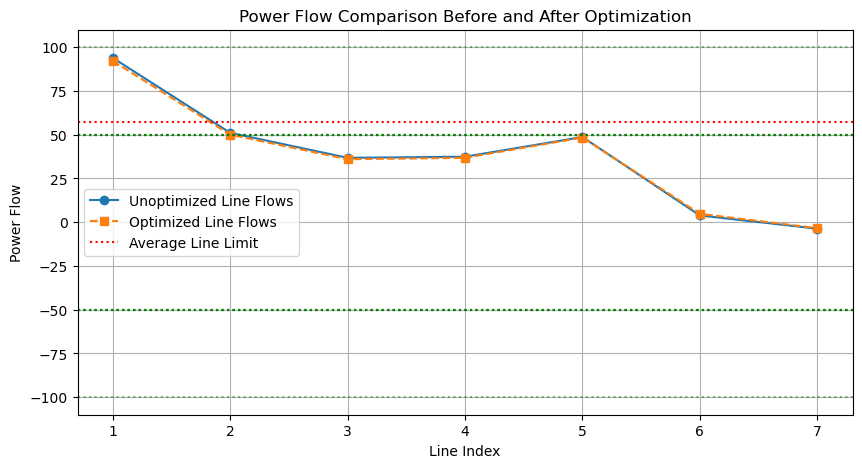

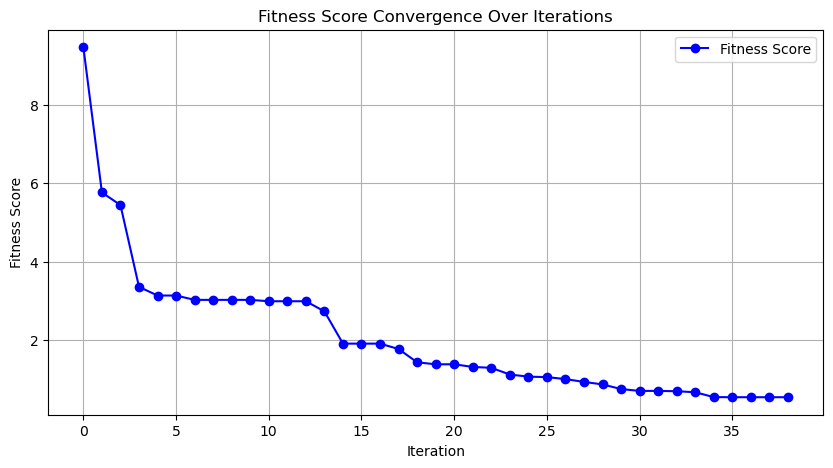

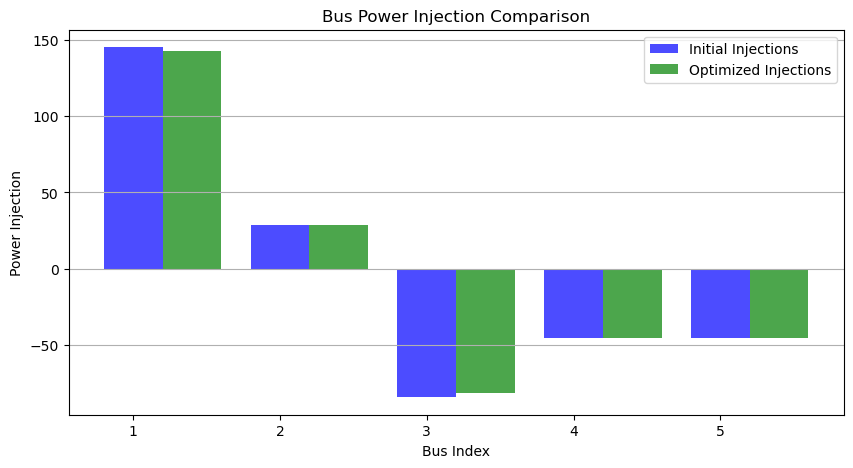

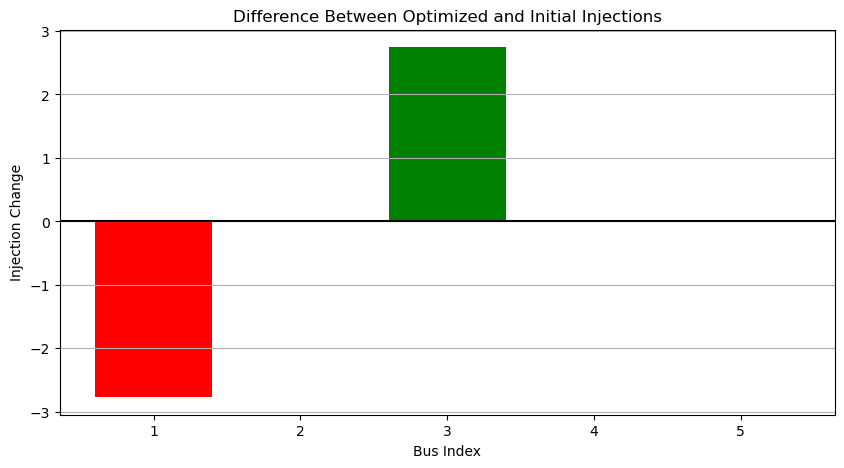


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[142.22927836]
 [ 28.99997298]
 [-81.25494334]
 [-44.97755571]
 [-44.99675229]]

Sum of Optimized Power Injections (Should be 0):  -7.105427357601002e-15

Resultant Line Flows After Optimization (7x1):
 [[92.17943384]
 [50.04984452]
 [36.00737345]
 [36.80173093]
 [48.37102827]
 [ 4.79255137]
 [-3.37427597]]

Changes to Power Injections:
Absolute Changes: [2.77072164e+00 2.70163132e-05 2.74505666e+00 2.24442935e-02
 3.247


Do you want to save the results to a file? (y/n):  n

Do you want to run another scenario? (y/n):  n



Thank you for using the Hybrid Power Flow Optimizer!


In [5]:
#optimum without price constraint  till the first drcimal
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import time  # Import the time module for performance tracking


# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        """
        Initialize the optimizer.

        Parameters:
        - A_matrix: The power flow matrix.
        - line_limits: The line capacity limits.
        - memory_size: The size of the solution memory.
        - max_sum_diff: The maximum allowed sum of differences between original and optimized injections.
        """
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        self.algorithm_weights = {'OOA': 0.3, 'KHA': 0.3, 'SHO': 0.4}  # Initial algorithm weights
        self.adaptive_weights = True  # Control adaptive weights.
        self.generator_costs = {} # Dictionary to store generator costs

    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using a hybrid of OOA, KHA, and SHO algorithms with memory.

        Parameters:
        - B: Original power injections.
        - iterations: Maximum number of iterations.
        - population_size: Size of the population.
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis).
        """
        start_time = time.time()  # Record the start time

        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size // 2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size // 2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population
        initial_population[0] = B.copy()

        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)

        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        algorithm_successes = {'OOA': 0, 'KHA': 0, 'SHO': 0}  # Track algorithm success
        stagnation_counter = 0
        previous_best_fitness = best_fitness

        # Main optimization loop
        for iteration in range(iterations):
            if self.adaptive_weights:
                self._update_algorithm_weights(algorithm_successes)  # Update weights adaptively

            new_population = []

            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Select algorithm based on adaptive weights
                algorithm = random.choices(list(self.algorithm_weights.keys()),
                                           weights=list(self.algorithm_weights.values()), k=1)[0]

                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration,
                                                                 iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                # Ensure power balance
                new_solution -= np.mean(new_solution)

                # Add to new population
                new_population.append(new_solution)

                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)

                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    algorithm_successes[algorithm] += 1  # Increment algorithm success counter

                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}, Best Fitness: {best_fitness:.6f}")
                else:
                    algorithm_successes[algorithm] *= 0.9  # Decay success if not improved

            # Replace old population with new population
            initial_population = new_population

            # Record fitness history
            fitness_history.append(best_fitness)

            # Check for stagnation and adapt algorithms if necessary
            if abs(best_fitness - previous_best_fitness) < 1e-6:
                stagnation_counter += 1
                if stagnation_counter >= 10:  # Increased stagnation threshold
                    print("Stagnation detected.  Re-initializing some solutions.")
                    # Re-initialize a portion of the population to increase diversity
                    for i in range(population_size // 4):  # Re-initialize 25% of population
                        initial_population[random.randint(0, population_size - 1)] = self._generate_random_solution(B)
                    stagnation_counter = 0  # Reset counter
            else:
                stagnation_counter = 0
            previous_best_fitness = best_fitness

            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break

        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)

        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)

        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)

        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count / total * 100:.1f}%")

        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")

        end_time = time.time()  # Record the end time
        print(f"Optimization time: {end_time - start_time:.2f} seconds")

        return best_solution, fitness_history, np.dot(self.A, best_solution)

    def _update_algorithm_weights(self, algorithm_successes):
        """
        Dynamically update algorithm weights based on their recent success.
        """
        total_success = sum(algorithm_successes.values())
        if total_success > 0:
            for algo in self.algorithm_weights:
                # Update weight based on success rate, with a smoothing factor
                self.algorithm_weights[algo] = 0.8 * self.algorithm_weights[algo] + 0.2 * (
                        algorithm_successes[algo] / total_success)
        else:
            # If no success, keep weights as they are
            pass

        # Normalize weights to sum to 1
        total_weight = sum(self.algorithm_weights.values())
        for algo in self.algorithm_weights:
            self.algorithm_weights[algo] /= total_weight

    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint.

        Parameters:
        - solution: The current solution.
        - original_B: The original power injections.
        - steps: Number of steps to take in the minimization process.
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)

        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)

            # Ensure power balance
            new_solution -= np.mean(new_solution)

            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")

        return best_solution

    def _generate_random_solution(self, B):
        """
        Generate a random solution based on the original B that respects the sum diff constraint.

        Parameters:
        - B: The original power injections.
        """
        max_attempts = 10
        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean()
            random_solution -= np.mean(random_solution)  # Ensure power balance

            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution

        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint.

        Parameters:
        - solution: Current solution to evaluate.
        - original_B: Original power injections.
        - alpha: Weight for minimizing changes (higher = more emphasis).
        """
        C = np.dot(self.A, solution)

        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, np.abs(C.flatten()) - self.line_limits))

        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)

        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10

        # Calculate rescheduling cost using generator costs
        rescheduling_cost = self._calculate_rescheduling_cost(solution, original_B)


        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty + rescheduling_cost

    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)."""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        # Round to 1 decimal place for comparison
        C_rounded = np.round(np.abs(C.flatten()), 1)
        line_limits_rounded = np.round(self.line_limits, 1)
        line_constraints_met = np.all(C_rounded <= line_limits_rounded)

        return line_constraints_met

    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution."""
        if not self.memory:
            return None

        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')

        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)

            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))

            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B

        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory."""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy."""
        solution = population[index].copy()

        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()

        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]

        # Binary success indicator (simplified)
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution,
                                                                                          solution) else 0

        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)

            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)

        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy."""
        solution = population[index].copy()

        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5  # Inertia weight
        c_best = 2  # Best krill effect
        c_rand = 1  # Random krill effect

        # Motion induction (other krill effect)
        N_old = 0  # Previous motion
        neighbors = random.sample(population, min(3, len(population) - 1))

        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)

        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)

        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()

        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)

        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D

        return new_solution

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy."""
        solution = population[index].copy()

        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0

        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index],
                                       min(3, len(population) - 1))
        random_solutions = [population[i] for i in random_indices]

        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)

        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha

            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2

        return new_solution

    def _calculate_rescheduling_cost(self, new_solution, original_B):
        """
        Calculate the total rescheduling cost based on generator price bids.

        Parameters:
        - new_solution: The new power injections after rescheduling.
        - original_B: The original power injections.

        Returns:
        - total_cost: The total cost of rescheduling.
        """
        total_cost = 0
        for g in range(self.num_buses):  # Iterate over all generators
            delta_pg = new_solution[g] - original_B[g]  # Change in power generation
            if g in self.generator_costs:
                cost_per_mwh = self.generator_costs[g]
                total_cost += cost_per_mwh * delta_pg
            else:
                print(f"Warning: Cost for generator {g+1} not found.  Using 0.")
        return total_cost



# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0, generator_costs=None):
    """
    Optimize power flow using the HybridPowerFlowOptimizer.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - iterations: The maximum number of iterations.
    - alpha: The weighting factor for minimizing changes.
    - max_sum_diff: Maximum allowed sum of differences.
    - generator_costs: A dictionary of generator costs.
    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    """
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    if generator_costs:
        optimizer.generator_costs = generator_costs
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)

    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)

    return B_optimized, fitness_history, C_optimized, C_unoptimized



# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0,
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001, generator_costs=None):
    """
    Incrementally find the minimum sufficient sum_diff that leads to a feasible solution.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - alpha: Weighting factor.
    - start_sum_diff: Starting sum difference.
    - step_size: Initial step size.
    - max_attempts: Maximum number of attempts.
    - min_step_size: Minimum step size allowed.
    - generator_costs: Dictionary of generator costs.

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    - best_feasible_sum_diff: The minimum sum difference found.
    """
    print("Starting incremental search for minimum sum difference...")

    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')

    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(np.round(np.abs(C_unoptimized.flatten()), 1) <= np.round(line_limits, 1)):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0

    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")

    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None

    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")

        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            if generator_costs:
                optimizer.generator_costs = generator_costs
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=150, alpha=alpha)

            # Check if constraints are satisfied
            is_feasible = np.all(np.round(np.abs(C_optimized.flatten()), 1) <= np.round(line_limits, 1))

            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))

            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")

                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff

                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_dff:.8f}")

                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(
                            f"Switching to binary search between {last_failing_sum_diff:.8f} and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff

                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")

                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                            if generator_costs:
                                 optimizer.generator_costs = generator_costs
                            B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=150, alpha=alpha)

                            if np.all(np.round(np.abs(C_opt.flatten()), 1) <= np.round(line_limits, 1)):
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")

                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")

                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")

                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff

                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff

                # Reduce step size for more precise search.  Important for fine tuning.
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5) # Subtract a few steps worth
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")

            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")

                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff

                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size

        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size

    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)  # Try with a large value
        if generator_costs:
            optimizer.generator_costs = generator_costs
        B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0

    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff




# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    """
    Visualize and report the results of the power flow optimization.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - B_optimized: The optimized power injections.
    - C_optimized: The optimized line flows.
    - C_unoptimized: The unoptimized line flows.
    - line_limits: The line capacity limits.
    - fitness_history: The history of fitness values during optimization.
    - max_sum_diff: The maximum allowed sum of differences.
    """
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b',
                 label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i + 0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7,
            color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)

    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B) / np.linalg.norm(B) * 100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")

    # Check that constraints are satisfied
    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {(np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized))) / np.sum(abs(C_unoptimized)) * 100:.6f}%")



# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
        [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
        [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
        [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for generator costs
    generator_costs = {}
    for i in range(A.shape[1]):  # Number of generators is the number of columns in A
        cost = float(input(f"Enter cost (RS/MWh) for generator {i + 1}: "))
        generator_costs[i] = cost

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                      line_limits,
                                                                                                      alpha=alpha, generator_costs=generator_costs)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      fitness_history, max_sum_diff=optimal_sum_diff)

    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")

            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")

            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i + 1}: {limit}\n")

            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

            # Check for violations
            violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(
                        f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")

            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")

            print(f"Results saved to {filename}")

    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        # The main() function was removed to avoid recursion issues.  Here we just re-execute the main logic.
        if __name__ == "__main__":
            # Define the given 7x5 matrix (Power Flow Coefficients)
            A = np.array([
                [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
                [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
                [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
                [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
                [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
                [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
                [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
            ])

            # User input for Line Power Limits (7 lines)
            print("Enter power limits for each line:")
            line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

            # User input for Bus Injection Matrix B (5x1)
            print("\nEnter power injections for each bus:")
            B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

             # User input for generator costs
            generator_costs = {}
            for i in range(A.shape[1]):  # Number of generators is the number of columns in A
                cost = float(input(f"Enter cost (RS/MWh) for generator {i + 1}: "))
                generator_costs[i] = cost

            # User input for weighting factor (how much to prioritize minimal changes)
            alpha = float(input(
                "\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

            # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
            print("\nStarting incremental optimization to find minimum required sum of differences...")
            B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                              line_limits,
                                                                                                              alpha=alpha, generator_costs=generator_costs)
            print("\nVisualization of optimization results with minimum required sum of differences...")
            visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                              fitness_history, max_sum_diff=optimal_sum_diff)

            print("\nOptimization complete!")
            print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

            # Ask user if they want to save the results
            save_results = input("\nDo you want to save the results to a file? (y/n): ")
            if save_results.lower() == 'y':
                filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

                with open(filename, 'w') as f:
                    f.write("Power Flow Optimization Results\n")
                    f.write("==============================\n\n")

                    f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
                    for row in A:
                        f.write(str(row) + "\n")

                    f.write("\nLine Power Limits:\n")
                    for i, limit in enumerate(line_limits):
                        f.write(f"Line {i + 1}: {limit}\n")

                    f.write("\nInitial Power Injections (B, 5x1):\n")
                    for i, injection in enumerate(B):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
                    for i, injection in enumerate(B_optimized):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
                    for i, flow in enumerate(C_unoptimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
                    for i, flow in enumerate(C_optimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

                    # Check for violations
                    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
                    if len(violations) > 0:
                        f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                        for line in violations:
                            f.write(
                                f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
                    else:
                        f.write("\nAll line constraints satisfied!\n")

                    f.write("\nOptimization Parameters:\n")
                    f.write(f"Alpha (weight for minimal changes): {alpha}\n")

                    print(f"Results saved to {filename}")
            run_again = input("\nDo you want to run another scenario? (y/n): ")
            if run_again.lower() == 'n':
                print("\nThank you for using the Hybrid Power Flow Optimizer!")
            else:
                print("\nRestarting program...\n")
    else:
        print("\nThank you for using the Hybrid Power Flow Optimizer!")


In [19]:
#optimum without price constraint  till the first drcimal
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import time  # Import the time module for performance tracking


# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0, generator_costs=None):
        """
        Initialize the optimizer.

        Parameters:
        - A_matrix: The power flow matrix.
        - line_limits: The line capacity limits.
        - memory_size: The size of the solution memory.
        - max_sum_diff: The maximum allowed sum of differences between original and optimized injections.
        """
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        self.algorithm_weights = {'OOA': 0.3, 'KHA': 0.3, 'SHO': 0.4}  # Initial algorithm weights
        self.adaptive_weights = True  # Control adaptive weights.
        self.generator_costs = generator_costs # Cost coefficients for each generator

    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using a hybrid of OOA, KHA, and SHO algorithms with memory.

        Parameters:
        - B: Original power injections.
        - iterations: Maximum number of iterations.
        - population_size: Size of the population.
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis).
        """
        start_time = time.time()  # Record the start time

        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size // 2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size // 2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population
        initial_population[0] = B.copy()

        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)

        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        algorithm_successes = {'OOA': 0, 'KHA': 0, 'SHO': 0}  # Track algorithm success
        stagnation_counter = 0
        previous_best_fitness = best_fitness

        # Main optimization loop
        for iteration in range(iterations):
            if self.adaptive_weights:
                self._update_algorithm_weights(algorithm_successes)  # Update weights adaptively

            new_population = []

            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Select algorithm based on adaptive weights
                algorithm = random.choices(list(self.algorithm_weights.keys()),
                                           weights=list(self.algorithm_weights.values()), k=1)[0]

                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration,
                                                                 iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                # Ensure power balance
                new_solution -= np.mean(new_solution)

                # Add to new population
                new_population.append(new_solution)

                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)

                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    algorithm_successes[algorithm] += 1  # Increment algorithm success counter

                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}, Best Fitness: {best_fitness:.6f}")
                else:
                    algorithm_successes[algorithm] *= 0.9  # Decay success if not improved

            # Replace old population with new population
            initial_population = new_population

            # Record fitness history
            fitness_history.append(best_fitness)

            # Check for stagnation and adapt algorithms if necessary
            if abs(best_fitness - previous_best_fitness) < 1e-6:
                stagnation_counter += 1
                if stagnation_counter >= 10:  # Increased stagnation threshold
                    print("Stagnation detected.  Re-initializing some solutions.")
                    # Re-initialize a portion of the population to increase diversity
                    for i in range(population_size // 4):  # Re-initialize 25% of population
                        initial_population[random.randint(0, population_size - 1)] = self._generate_random_solution(B)
                    stagnation_counter = 0  # Reset counter
            else:
                stagnation_counter = 0
            previous_best_fitness = best_fitness

            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break

        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)

        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)

        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)

        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count / total * 100:.1f}%")

        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")

        end_time = time.time()  # Record the end time
        optimization_time = end_time - start_time
        print(f"Optimization time: {optimization_time:.2f} seconds")

        return best_solution, fitness_history, np.dot(self.A, best_solution), optimization_time

    def _update_algorithm_weights(self, algorithm_successes):
        """
        Dynamically update algorithm weights based on their recent success.
        """
        total_success = sum(algorithm_successes.values())
        if total_success > 0:
            for algo in self.algorithm_weights:
                # Update weight based on success rate, with a smoothing factor
                self.algorithm_weights[algo] = 0.8 * self.algorithm_weights[algo] + 0.2 * (
                        algorithm_successes[algo] / total_success)
        else:
            # If no success, keep weights as they are
            pass

        # Normalize weights to sum to 1
        total_weight = sum(self.algorithm_weights.values())
        for algo in self.algorithm_weights:
            self.algorithm_weights[algo] /= total_weight

    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint.

        Parameters:
        - solution: The current solution.
        - original_B: The original power injections.
        - steps: Number of steps to take in the minimization process.
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)

        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)

            # Ensure power balance
            new_solution -= np.mean(new_solution)

            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")

        return best_solution

    def _generate_random_solution(self, B):
        """
        Generate a random solution based on the original B that respects the sum diff constraint.

        Parameters:
        - B: The original power injections.
        """
        max_attempts = 10

        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean()
            random_solution -= np.mean(random_solution)  # Ensure power balance

            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution

        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint.

        Parameters:
        - solution: Current solution to evaluate.
        - original_B: Original power injections.
        - alpha: Weight for minimizing changes (higher = more emphasis).
        """
        C = np.dot(self.A, solution)

        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, np.abs(C.flatten()) - self.line_limits))

        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)

        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10

        # Generator cost calculation
        if self.generator_costs:
            total_cost = 0
            for i, cost in self.generator_costs.items():
                total_cost += cost * solution[i, 0]  # Cost times power output
        else:
            total_cost = 0

        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty + total_cost

    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)."""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        # Round to 1 decimal place for comparison
        C_rounded = np.round(np.abs(C.flatten()), 1)
        line_limits_rounded = np.round(self.line_limits, 1)
        line_constraints_met = np.all(C_rounded <= line_limits_rounded)

        return line_constraints_met

    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution."""
        if not self.memory:
            return None

        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')

        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)

            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))

            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B

        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory."""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy."""
        solution = population[index].copy()

        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()

        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]

        # Binary success indicator (simplified)
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution,
                                                                                          solution) else 0

        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)

            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)

        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy."""
        solution = population[index].copy()

        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5  # Inertia weight
        c_best = 2  # Best krill effect
        c_rand = 1  # Random krill effect

        # Motion induction (other krill effect)
        N_old = 0  # Previous motion
        neighbors = random.sample(population, min(3, len(population) - 1))

        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)

        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)

        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()

        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)

        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D

        return new_solution

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy."""
        solution = population[index].copy()

        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0
        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index],
                                       min(3, len(population) - 1))
        random_solutions = [population[i] for i in random_indices]

        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)

        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha

            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2

        return new_solution


# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0, generator_costs=None):
    """
    Optimize power flow using the HybridPowerFlowOptimizer.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - iterations: The maximum number of iterations.
    - alpha: The weighting factor for minimizing changes.
    - max_sum_diff: Maximum allowed sum of differences.
    - generator_costs: A dictionary containing the cost coefficients for the generators.
    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    """
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff, generator_costs=generator_costs)

    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)

    start_time = time.time()
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized, optimization_time = optimizer.optimize(B, iterations, alpha=alpha)
    end_time = time.time()
    total_time = end_time - start_time

    return B_optimized, fitness_history, C_optimized, C_unoptimized, total_time



# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0,
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001, generator_costs=None):
    """
    Incrementally find the minimum sufficient sum_diff that leads to a feasible solution.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - alpha: Weighting factor.
    - start_sum_diff: Starting sum difference.
    - step_size: Initial step size.
    - max_attempts: Maximum number of attempts.
    - min_step_size: Minimum step size allowed.
    - generator_costs:  A dictionary containing the cost coefficients for the generators.

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    - best_feasible_sum_diff: The minimum sum difference found.
    """
    print("Starting incremental search for minimum sum difference...")

    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')

    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(np.round(np.abs(C_unoptimized.flatten()), 1) <= np.round(line_limits, 1)):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0, 0.0

    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")

    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None

    start_time = time.time() # start the timer
    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")

        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff, generator_costs=generator_costs)
            B_optimized, fitness_history, C_optimized, optimization_time = optimizer.optimize(B, iterations=150, alpha=alpha)

            # Check if constraints are satisfied
            is_feasible = np.all(np.round(np.abs(C_optimized.flatten()), 1) <= np.round(line_limits, 1))

            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))

            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")

                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff

                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.8f}")

                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(f"Switching to binary search between {last_failing_sum_diff:.8f} and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff

                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")

                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid, generator_costs=generator_costs)
                            B_opt, fit_hist, C_opt, optimization_time = optimizer.optimize(B, iterations=150, alpha=alpha)

                            if np.all(np.round(np.abs(C_opt.flatten()), 1) <= np.round(line_limits, 1)):
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")

                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")

                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")

                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        end_time = time.time()
                        total_time = end_time - start_time
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff, total_time

                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    end_time = time.time()
                    total_time = end_time - start_time
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff, total_time

                # Reduce step size for more precise search.  Important for fine tuning.
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5) # Subtract a few steps worth
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")

            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")

                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff

                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size

        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size

    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0, generator_costs=generator_costs)  # Try with a large value
        B_optimized, fitness_history, C_optimized, optimization_time = optimizer.optimize(B, iterations=200, alpha=alpha)
        end_time = time.time()
        total_time = end_time - start_time
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0, total_time

    end_time = time.time()
    total_time = end_time - start_time
    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff, total_time



# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0, generator_costs=None):
    """
    Visualize and report the results of the power flow optimization.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - B_optimized: The optimized power injections.
    - C_optimized: The optimized line flows.
    - C_unoptimized: The unoptimized line flows.
    - line_limits: The line capacity limits.
    - fitness_history: The history of fitness values during optimization.
    - max_sum_diff: The maximum allowed sum of differences.
    """
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b',
                 label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i + 0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7,
            color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)

    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B) / np.linalg.norm(B) * 100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")

    # Check that constraints are satisfied
    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Calculate and print total cost
    if generator_costs:
        total_cost = 0
        for i, cost in generator_costs.items():
            total_cost += cost * B_optimized[i, 0]
        print(f"Total Generation Cost: {total_cost:.2f} RS/MWh")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {(np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized))) / np.sum(abs(C_unoptimized)) * 100:.6f}%")



# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
        [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
        [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
        [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for generator costs
    generator_costs = {}
    for i in range(A.shape[1]):  # Number of generators is the number of columns in A
        cost = float(input(f"Enter cost (RS/MWh) for generator {i + 1}: "))
        generator_costs[i] = cost

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff, total_time = find_minimum_sum_diff(A, B,
                                                                                                      line_limits,
                                                                                                      alpha=alpha, generator_costs=generator_costs)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      fitness_history, max_sum_diff=optimal_sum_diff, generator_costs=generator_costs)

    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")
    print(f"Total time taken: {total_time:.2f} seconds")

    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")

            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")

            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i + 1}: {limit}\n")

            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")
            f.write(f"Total Time Taken: {total_time:.2f} seconds\n")

            # Check for violations
            violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(
                        f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")

             # Calculate and write total cost
            if generator_costs:
                total_cost = 0
                for i, cost in generator_costs.items():
                    total_cost += cost * B_optimized[i, 0]
                f.write(f"Total Generation Cost: {total_cost:.2f} RS/MWh\n")

            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")

            print(f"Results saved to {filename}")

    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        # The main() function was removed to avoid recursion issues.  Here we just re-execute the main logic.
        if __name__ == "__main__":
            # Define the given 7x5 matrix (Power Flow Coefficients)
            A = np.array([
                [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
                [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
                [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
                [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
                [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
                [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
                [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
            ])

            # User input for Line Power Limits (7 lines)
            print("Enter power limits for each line:")
            line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

            # User input for Bus Injection Matrix B (5x1)
            print("\nEnter power injections for each bus:")
            B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

             # User input for generator costs
            generator_costs = {}
            for i in range(A.shape[1]):  # Number of generators is the number of columns in A
                cost = float(input(f"Enter cost (RS/MWh) for generator {i + 1}: "))
                generator_costs[i] = cost

            # User input for weighting factor (how much to prioritize minimal changes)
            alpha = float(input(
                "\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

            # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
            print("\nStarting incremental optimization to find minimum required sum of differences...")
            B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff, total_time = find_minimum_sum_diff(A, B,
                                                                                                              line_limits,
                                                                                                              alpha=alpha, generator_costs=generator_costs)
            print("\nVisualization of optimization results with minimum required sum of differences...")
            visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                              fitness_history, max_sum_diff=optimal_sum_diff, generator_costs=generator_costs)

            print("\nOptimization complete!")
            print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")
            print(f"Total time taken: {total_time:.2f} seconds")

            # Ask user if they want to save the results
            save_results = input("\nDo you want to save the results to a file? (y/n): ")
            if save_results.lower() == 'y':
                filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

                with open(filename, 'w') as f:
                    f.write("Power Flow Optimization Results\n")
                    f.write("==============================\n\n")

                    f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
                    for row in A:
                        f.write(str(row) + "\n")

                    f.write("\nLine Power Limits:\n")
                    for i, limit in enumerate(line_limits):
                        f.write(f"Line {i + 1}: {limit}\n")

                    f.write("\nInitial Power Injections (B, 5x1):\n")
                    for i, injection in enumerate(B):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
                    for i, injection in enumerate(B_optimized):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
                    for i, flow in enumerate(C_unoptimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
                    for i, flow in enumerate(C_optimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")
                    f.write(f"Total Time Taken: {total_time:.2f} seconds\n")

                    # Check for violations
                    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
                    if len(violations) > 0:
                        f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                        for line in violations:
                            f.write(
                                f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
                    else:
                        f.write("\nAll line constraints satisfied!\n")

                    # Calculate and write total cost
                    if generator_costs:
                        total_cost = 0
                        for i, cost in generator_costs.items():
                            total_cost += cost * B_optimized[i, 0]
                        f.write(f"Total Generation Cost: {total_cost:.2f} RS/MWh\n")

                    f.write("\nOptimization Parameters:\n")
                    f.write(f"Alpha (weight for minimal changes): {alpha}\n")

                    print(f"Results saved to {filename}")
            run_again = input("\nDo you want to run another scenario? (y/n): ")
            if run_again.lower() == 'n':
                print("\nThank you for using the Hybrid Power Flow Optimizer!")
            else:
                print("\nRestarting program...\n")
    else:
        print("\nThank you for using the Hybrid Power Flow Optimizer!")


Enter power limits for each line:


KeyboardInterrupt: Interrupted by user

Enter power limits for each line:


Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50



Enter power injections for each bus:


Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45

Enter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9):  1



Enter generator cost coefficients (cost per unit of power injection):


Enter cost coefficient for Bus 1 (0 if no generator):  4
Enter cost coefficient for Bus 2 (0 if no generator):  4
Enter cost coefficient for Bus 3 (0 if no generator):  0
Enter cost coefficient for Bus 4 (0 if no generator):  0
Enter cost coefficient for Bus 5 (0 if no generator):  0



Starting incremental optimization to find minimum required sum of differences...
Starting incremental search for minimum sum difference...
Using adaptive step size: 0.00696000

Attempt 1: Testing max_sum_diff = 0.00000000
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected. 

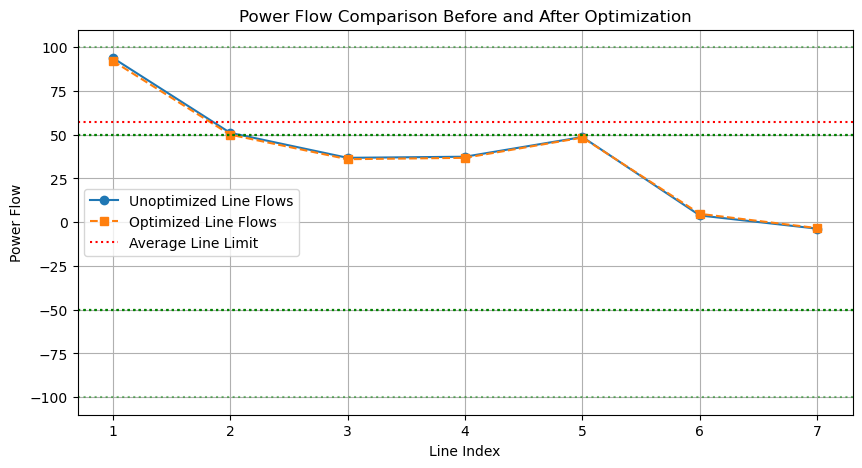

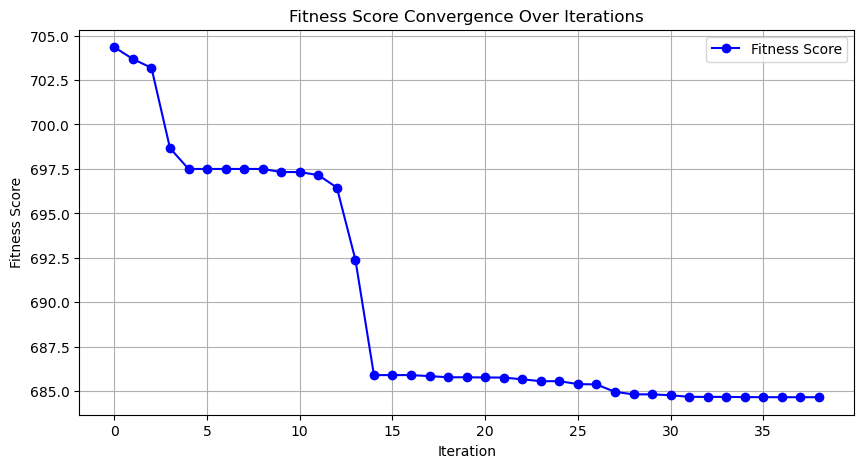

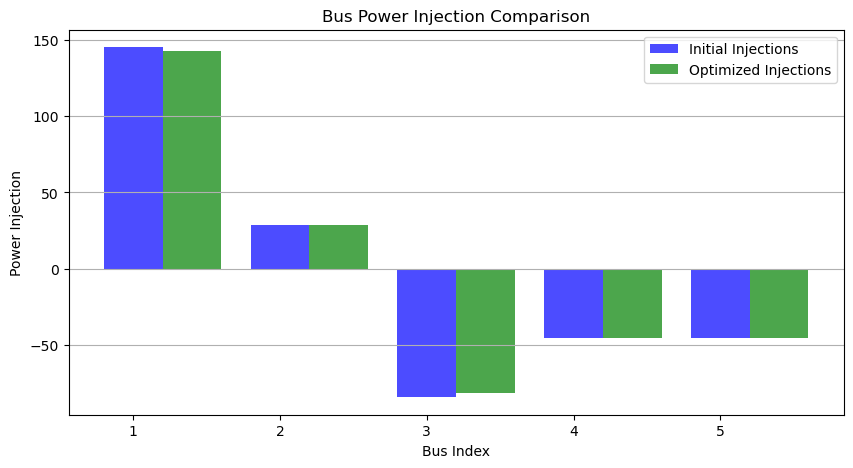

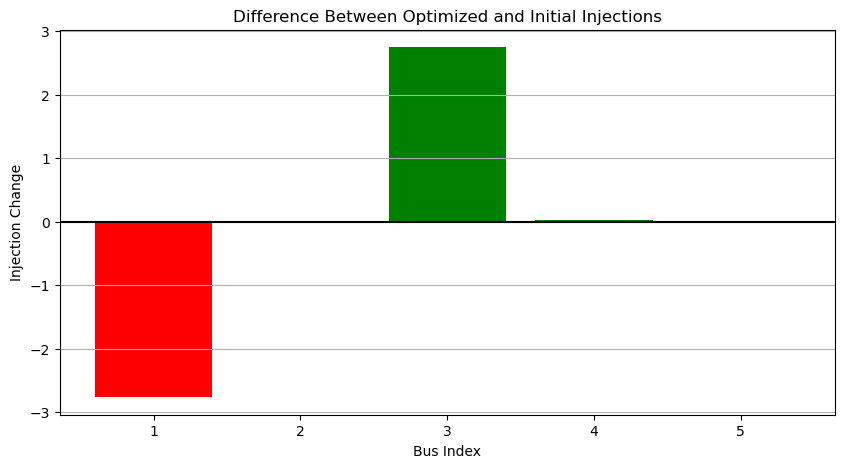


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[142.23290806]
 [ 28.99642611]
 [-81.25389674]
 [-44.97525998]
 [-45.00017746]]

Sum of Optimized Power Injections (Should be 0):  -7.105427357601002e-15

Resultant Line Flows After Optimization (7x1):
 [[92.18291515]
 [50.04999291]
 [36.00641097]
 [36.80080725]
 [48.37284877]
 [ 4.79278387]
 [-3.37267131]]

Changes to Power Injections:
Absolute Changes: [2.76709194e+00 3.57388643e-03 2.74610326e+00 2.47400211e-02
 1.774


Do you want to save the results to a file? (y/n):  y
Enter filename (default: power_flow_results.txt):  


Results saved to power_flow_results.txt



Do you want to run another scenario? (y/n):  n


In [27]:
#optimum without price constraint  till the first drcimal
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import time  # Import the time module for performance tracking


# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0, generator_costs=None):
        """
        Initialize the optimizer.

        Parameters:
        - A_matrix: The power flow matrix.
        - line_limits: The line capacity limits.
        - memory_size: The size of the solution memory.
        - max_sum_diff: The maximum allowed sum of differences between original and optimized injections.
        """
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        self.algorithm_weights = {'OOA': 0.3, 'KHA': 0.3, 'SHO': 0.4}  # Initial algorithm weights
        self.adaptive_weights = True  # Control adaptive weights.
        self.generator_costs = generator_costs # Cost coefficients for each generator

    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using a hybrid of OOA, KHA, and SHO algorithms with memory.

        Parameters:
        - B: Original power injections.
        - iterations: Maximum number of iterations.
        - population_size: Size of the population.
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis).
        """
        start_time = time.time()  # Record the start time

        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size // 2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size // 2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population
        initial_population[0] = B.copy()

        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)

        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        algorithm_successes = {'OOA': 0, 'KHA': 0, 'SHO': 0}  # Track algorithm success
        stagnation_counter = 0
        previous_best_fitness = best_fitness

        # Main optimization loop
        for iteration in range(iterations):
            if self.adaptive_weights:
                self._update_algorithm_weights(algorithm_successes)  # Update weights adaptively

            new_population = []

            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Select algorithm based on adaptive weights
                algorithm = random.choices(list(self.algorithm_weights.keys()),
                                           weights=list(self.algorithm_weights.values()), k=1)[0]

                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration,
                                                                 iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                # Ensure power balance
                new_solution -= np.mean(new_solution)

                # Add to new population
                new_population.append(new_solution)

                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)

                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    algorithm_successes[algorithm] += 1  # Increment algorithm success counter

                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}, Best Fitness: {best_fitness:.6f}")
                else:
                    algorithm_successes[algorithm] *= 0.9  # Decay success if not improved

            # Replace old population with new population
            initial_population = new_population

            # Record fitness history
            fitness_history.append(best_fitness)

            # Check for stagnation and adapt algorithms if necessary
            if abs(best_fitness - previous_best_fitness) < 1e-6:
                stagnation_counter += 1
                if stagnation_counter >= 10:  # Increased stagnation threshold
                    print("Stagnation detected.  Re-initializing some solutions.")
                    # Re-initialize a portion of the population to increase diversity
                    for i in range(population_size // 4):  # Re-initialize 25% of population
                        initial_population[random.randint(0, population_size - 1)] = self._generate_random_solution(B)
                    stagnation_counter = 0  # Reset counter
            else:
                stagnation_counter = 0
            previous_best_fitness = best_fitness

            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break

        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)

        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)

        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)

        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count / total * 100:.1f}%")

        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")

        end_time = time.time()  # Record the end time
        optimization_time = end_time - start_time
        print(f"Optimization time: {optimization_time:.2f} seconds")

        return best_solution, fitness_history, np.dot(self.A, best_solution), optimization_time

    def _update_algorithm_weights(self, algorithm_successes):
        """
        Dynamically update algorithm weights based on their recent success.
        """
        total_success = sum(algorithm_successes.values())
        if total_success > 0:
            for algo in self.algorithm_weights:
                # Update weight based on success rate, with a smoothing factor
                self.algorithm_weights[algo] = 0.8 * self.algorithm_weights[algo] + 0.2 * (
                        algorithm_successes[algo] / total_success)
        else:
            # If no success, keep weights as they are
            pass

        # Normalize weights to sum to 1
        total_weight = sum(self.algorithm_weights.values())
        for algo in self.algorithm_weights:
            self.algorithm_weights[algo] /= total_weight

    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint.

        Parameters:
        - solution: The current solution.
        - original_B: The original power injections.
        - steps: Number of steps to take in the minimization process.
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)

        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)

            # Ensure power balance
            new_solution -= np.mean(new_solution)

            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")

        return best_solution

    def _generate_random_solution(self, B):
        """
        Generate a random solution based on the original B that respects the sum diff constraint.

        Parameters:
        - B: The original power injections.
        """
        max_attempts = 10

        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean()
            random_solution -= np.mean(random_solution)  # Ensure power balance

            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution

        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint.

        Parameters:
        - solution: Current solution to evaluate.
        - original_B: Original power injections.
        - alpha: Weight for minimizing changes (higher = more emphasis).
        """
        C = np.dot(self.A, solution)

        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, np.abs(C.flatten()) - self.line_limits))

        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)

        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10

        # Generator cost calculation
        if self.generator_costs:
            total_cost = 0
            for i, cost in self.generator_costs.items():
                if solution[i, 0] > 0:  # Only consider positive power injections (generation)
                    total_cost += cost * solution[i, 0]  # Cost times power output
        else:
            total_cost = 0

        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty + total_cost

    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)."""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        # Round to 1 decimal place for comparison
        C_rounded = np.round(np.abs(C.flatten()), 1)
        line_limits_rounded = np.round(self.line_limits, 1)
        line_constraints_met = np.all(C_rounded <= line_limits_rounded)

        return line_constraints_met

    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution."""
        if not self.memory:
            return None

        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')

        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)

            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))

            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B

        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory."""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy."""
        solution = population[index].copy()

        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()

        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]

        # Binary success indicator (simplified)
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution,
                                                                                          solution) else 0

        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)

            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)

        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy."""
        solution = population[index].copy()

        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5  # Inertia weight
        c_best = 2  # Best krill effect
        c_rand = 1  # Random krill effect

        # Motion induction (other krill effect)
        N_old = 0  # Previous motion
        neighbors = random.sample(population, min(3, len(population) - 1))

        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)

        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)

        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()

        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)

        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D

        return new_solution

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy."""
        solution = population[index].copy()

        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0

        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index],
                                       min(3, len(population) - 1))
        random_solutions = [population[i] for i in random_indices]

        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)

        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha

            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2

        return new_solution


# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0, generator_costs=None):
    """
    Optimize power flow using the HybridPowerFlowOptimizer.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - iterations: The maximum number of iterations.
    - alpha: The weighting factor for minimizing changes.
    - max_sum_diff: Maximum allowed sum of differences.
    - generator_costs: A dictionary containing the cost coefficients for the generators.
    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    """
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff, generator_costs=generator_costs)

    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)

    start_time = time.time()
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized, optimization_time = optimizer.optimize(B, iterations, alpha=alpha)
    end_time = time.time()
    total_time = end_time - start_time

    return B_optimized, fitness_history, C_optimized, C_unoptimized, total_time



# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0,
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001, generator_costs=None):
    """
    Incrementally find the minimum sufficient sum_diff that leads to a feasible solution.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - alpha: Weighting factor.
    - start_sum_diff: Starting sum difference.
    - step_size: Initial step size.
    - max_attempts: Maximum number of attempts.
    - min_step_size: Minimum step size allowed.
    - generator_costs:  A dictionary containing the cost coefficients for the generators.

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    - best_feasible_sum_diff: The minimum sum difference found.
    """
    print("Starting incremental search for minimum sum difference...")

    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')

    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(np.round(np.abs(C_unoptimized.flatten()), 1) <= np.round(line_limits, 1)):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0, 0.0

    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")

    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None

    start_time = time.time() # start the timer
    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")

        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff, generator_costs=generator_costs)
            B_optimized, fitness_history, C_optimized, optimization_time = optimizer.optimize(B, iterations=150, alpha=alpha)

            # Check if constraints are satisfied
            is_feasible = np.all(np.round(np.abs(C_optimized.flatten()), 1) <= np.round(line_limits, 1))

            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))

            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")

                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff

                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.8f}")

                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(f"Switching to binary search between {last_failing_sum_diff:.8f}and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff

                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")

                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid, generator_costs=generator_costs)
                            B_opt, fit_hist, C_opt, opt_time = optimizer.optimize(B, iterations=150, alpha=alpha)

                            if np.all(np.round(np.abs(C_opt.flatten()), 1) <= np.round(line_limits, 1)):
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")

                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")

                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")
                        end_time = time.time()
                        total_time = end_time - start_time

                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff, total_time

                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    end_time = time.time()
                    total_time = end_time - start_time
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff, total_time

                # Reduce step size for more precise search.  Important for fine tuning.
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5) # Subtract a few steps worth
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")

            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")

                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff

                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size

        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size

    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0, generator_costs=generator_costs)  # Try with a large value
        B_optimized, fitness_history, C_optimized, optimization_time = optimizer.optimize(B, iterations=200, alpha=alpha)
        end_time = time.time()
        total_time = end_time - start_time
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0, total_time

    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    end_time = time.time()
    total_time = end_time - start_time
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff, total_time



# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history,  optimization_time, max_sum_diff=4.0, generator_costs=None):
    """
    Visualize and report the results of the power flow optimization.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - B_optimized: The optimized power injections.
    - C_optimized: The optimized line flows.
    - C_unoptimized: The unoptimized line flows.
    - line_limits: The line capacity limits.
    - fitness_history: The history of fitness values during optimization.
    - max_sum_diff: The maximum allowed sum of differences.
    """
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b',
                 label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i + 0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7,
            color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)

    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B) / np.linalg.norm(B) * 100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")

    # Check that constraints are satisfied
    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Calculate and print total cost
    if generator_costs:
        total_cost = 0
        for i, cost_coeff in generator_costs.items():
            if B_optimized[i, 0] > 0:  # Only consider positive power injections
                total_cost += cost_coeff * B_optimized[i, 0]
        print(f"\nTotal Generation Cost: {total_cost:.2f}")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {(np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized))) / np.sum(abs(C_unoptimized)) * 100:.6f}%")
    print(f"\nOptimization Time: {optimization_time:.2f} seconds")



# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
        [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
        [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
        [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

    # User input for generator costs
    print("\nEnter generator cost coefficients (cost per unit of power injection):")
    generator_costs = {}
    for i in range(5):  # Assuming 5 buses, each can have a generator.
        cost = float(input(f"Enter cost coefficient for Bus {i + 1} (0 if no generator): "))
        generator_costs[i] = cost # store cost for each generator

    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff, optimization_time = find_minimum_sum_diff(A, B,
                                                                                                      line_limits,
                                                                                                      alpha=alpha, generator_costs=generator_costs)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      fitness_history, optimization_time, max_sum_diff=optimal_sum_diff, generator_costs=generator_costs)

    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")

            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")

            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i + 1}: {limit}\n")

            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

            # Check for violations
            violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(
                        f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")

            # Print generator costs
            f.write("\nGenerator Costs:\n")
            for i, cost in generator_costs.items():
                f.write(f"Bus {i + 1}: {cost:.2f} per unit of power\n")

            # Calculate and write total cost
            total_cost = 0
            for i, cost_coeff in generator_costs.items():
                if B_optimized[i, 0] > 0:  # Only consider positive power injections
                    total_cost += cost_coeff * B_optimized[i, 0]
            f.write(f"\nTotal Generation Cost: {total_cost:.2f}\n")
            f.write(f"\nOptimization Time: {optimization_time:.2f} seconds\n")

            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")

            print(f"Results saved to {filename}")

    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        # The main() function was removed to avoid recursion issues.  Here we just re-execute the main logic.
        if __name__ == "__main__":
            # Define the given 7x5 matrix (Power Flow Coefficients)
            A = np.array([
                [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
                [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
                [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
                [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
                [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
                [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
                [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
            ])

            # User input for Line Power Limits (7 lines)
            print("Enter power limits for each line:")
            line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

            # User input for Bus Injection Matrix B (5x1)
            print("\nEnter power injections for each bus:")
            B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

            # User input for weighting factor (how much to prioritize minimal changes)
            alpha = float(input(
                "\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

             # User input for generator costs
            print("\nEnter generator cost coefficients (cost per unit of power injection):")
            generator_costs = {}
            for i in range(5):  # Assuming 5 buses, each can have a generator.
                cost = float(input(f"Enter cost coefficient for Bus {i + 1} (0 if no generator): "))
                generator_costs[i] = cost # store cost for each generator

            # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
            print("\nStarting incremental optimization to find minimum required sum of differences...")
            B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff, optimization_time = find_minimum_sum_diff(A, B,
                                                                                                              line_limits,
                                                                                                              alpha=alpha, generator_costs=generator_costs)
            print("\nVisualization of optimization results with minimum required sum of differences...")
            visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                              fitness_history, optimization_time, max_sum_diff=optimal_sum_diff, generator_costs=generator_costs)

            print("\nOptimization complete!")
            print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

            # Ask user if they want to save the results
            save_results = input("\nDo you want to save the results to a file? (y/n): ")
            if save_results.lower() == 'y':
                filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

                with open(filename, 'w') as f:
                    f.write("Power Flow Optimization Results\n")
                    f.write("==============================\n\n")

                    f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
                    for row in A:
                        f.write(str(row) + "\n")

                    f.write("\nLine Power Limits:\n")
                    for i, limit in enumerate(line_limits):
                        f.write(f"Line {i + 1}: {limit}\n")

                    f.write("\nInitial Power Injections (B, 5x1):\n")
                    for i, injection in enumerate(B):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
                    for i, injection in enumerate(B_optimized):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
                    for i, flow in enumerate(C_unoptimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
                    for i, flow in enumerate(C_optimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

                    # Check for violations
                    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
                    if len(violations) > 0:
                        f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                        for line in violations:
                            f.write(
                                f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
                    else:
                        f.write("\nAll line constraints satisfied!\n")

                     # Print generator costs
                    f.write("\nGenerator Costs:\n")
                    for i, cost in generator_costs.items():
                        f.write(f"Bus {i + 1}: {cost:.2f} per unit of power\n")

                    # Calculate and write total cost
                    total_cost = 0
                    for i, cost_coeff in generator_costs.items():
                        if B_optimized[i, 0] > 0:  # Only consider positive power injections
                            total_cost += cost_coeff * B_optimized[i, 0]
                    f.write(f"\nTotal Generation Cost: {total_cost:.2f}\n")
                    f.write(f"\nOptimization Time: {optimization_time:.2f} seconds\n")

                    f.write("\nOptimization Parameters:\n")
                    f.write(f"Alpha (weight for minimal changes): {alpha}\n")

                    print(f"Results saved to {filename}")
            run_again = input("\nDo you want to run another scenario? (y/n): ")
            if run_again.lower('n'):
                print("\nThank you for using the Hybrid Power Flow Optimizer!")
            else:
                print("\nRestarting program...\n")
 


==================== New Power Flow Scenario ====================

Enter power limits for each of the 7 lines:


Enter absolute power limit for Line 1:  100
Enter absolute power limit for Line 2:  50
Enter absolute power limit for Line 3:  50
Enter absolute power limit for Line 4:  50
Enter absolute power limit for Line 5:  50
Enter absolute power limit for Line 6:  50
Enter absolute power limit for Line 7:  50



Enter power injections for each of the 5 buses:


Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45


Initial power injections sum is close to zero.



Enter alpha value (weight for minimal changes, 0.0-1.0, e.g., 0.7-0.95):  1



Starting incremental optimization to find minimum required sum of differences...
Starting incremental search for minimum sum difference...
Using initial adaptive step size: 0.06960000

--- Phase 1: Searching for first feasible max_sum_diff ---

Attempt 1: Testing max_sum_diff = 0.00000000

Applying final minimization step...
Starting minimization. Initial sum_diff: 0.00000000
Solution is already very close to original B.
Finished minimization. Final sum_diff: 0.00000000

Algorithm Contributions:
OOA: 36.4%
KHA: 34.9%
SHO: 28.7%

Final sum of differences: 0.00000000 (Target Max: 0.00000000)
✗ Solution is INFEASIBLE and within limit

Attempt 2: Testing max_sum_diff = 0.06960000

Applying final minimization step...
Starting minimization. Initial sum_diff: 0.06660989
Finished minimization. Final sum_diff: 0.06660989

Algorithm Contributions:
OOA: 37.0%
KHA: 35.9%
SHO: 27.1%

Final sum of differences: 0.06660989 (Target Max: 0.06960000)
✗ Solution is INFEASIBLE and within limit

Attempt 3:

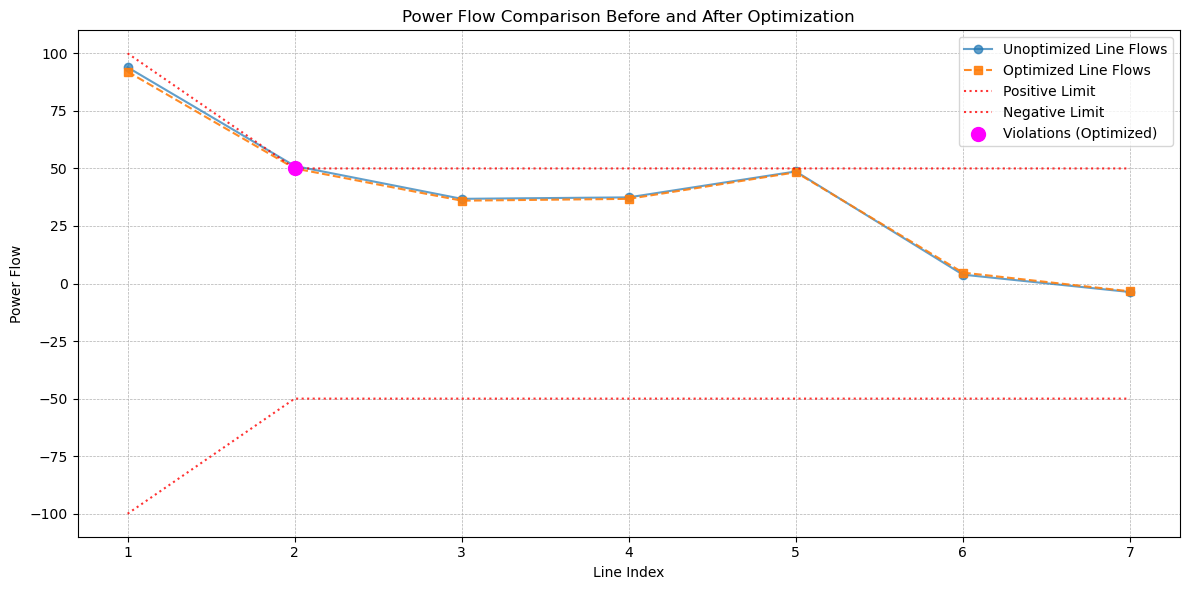

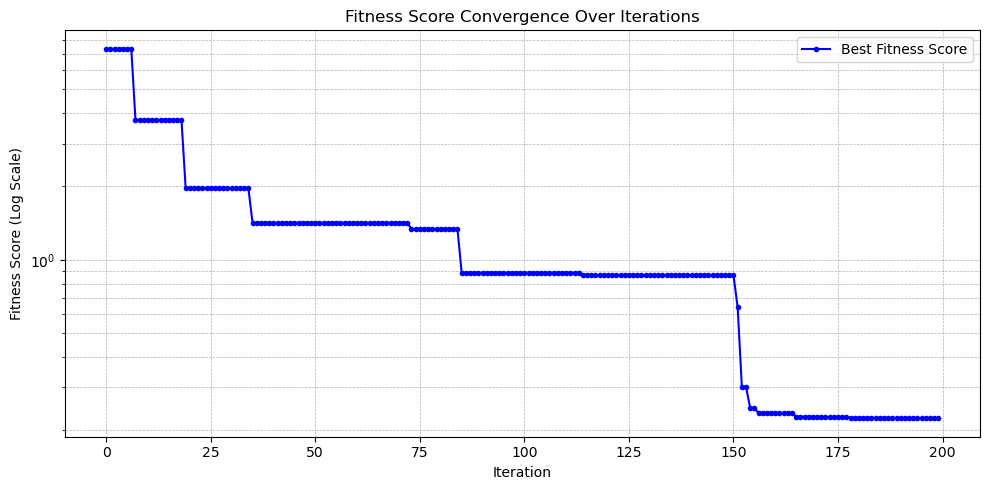

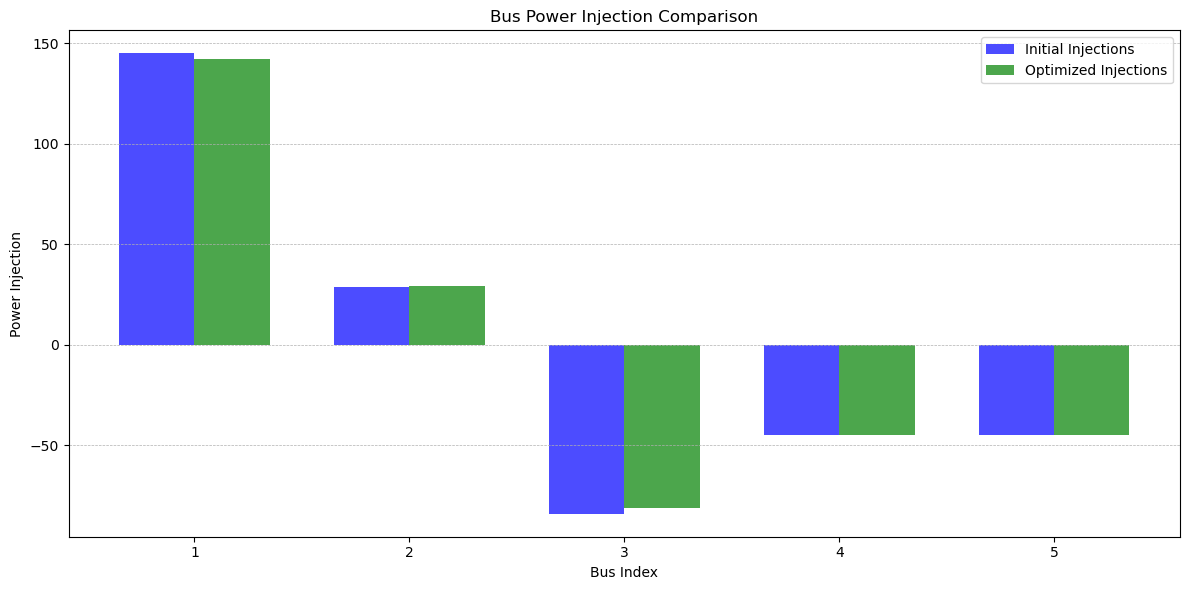

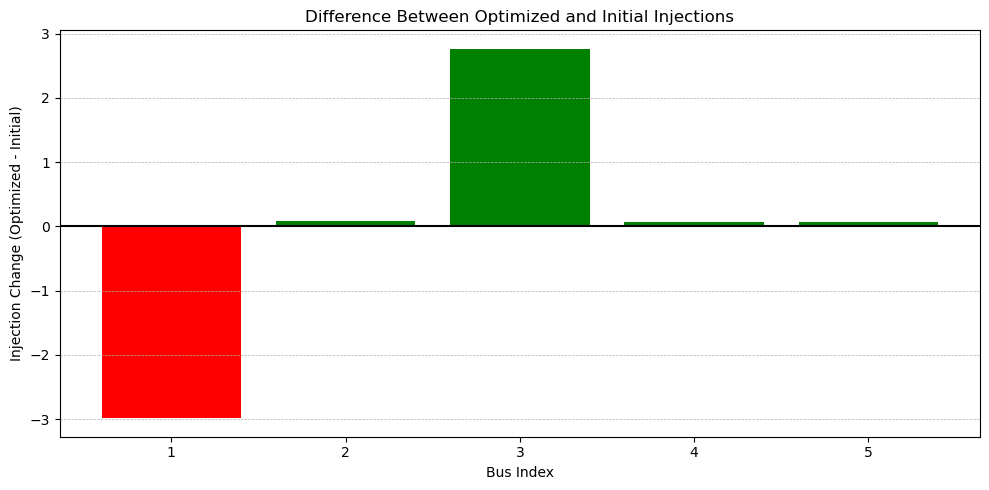


============================== RESULTS ==============================

Line Limits (7x1):
 [100.  50.  50.  50.  50.  50.  50.]

Initial Power Injections (B, 5x1):
 [145.  29. -84. -45. -45.]

Resultant Line Flows Before Optimization (7x1):
 [93.9223 51.0777 36.7968 37.4363 48.6902  3.8645 -3.6902]

----------------------------------------------------------------------

Optimized Power Injections (B_optimized, 5x1):
 [142.0155  29.091  -81.2381 -44.9289 -44.9395]
Sum of Optimized Power Injections (Should be near 0): 0.000000

Resultant Line Flows After Optimization (7x1):
 [92.0145 50.001  35.9973 36.7846 48.3243  4.7505 -3.3848]
----------------------------------------------------------------------

Changes to Power Injections:
  Absolute Changes: [2.9845 0.091  2.7619 0.0711 0.0605]
  Sum of Absolute Changes (Optimal Found): 5.96902368
  Average Percentage Change (for non-zero initial): 1.19%
  Total Deviation (L2 Norm): 4.0685
  Relative Deviation (L2 Norm): 2.24%

Constraint Check


Do you want to save the detailed results to a file? (y/n):  n

Do you want to run another scenario? (y/n):  n



Thank you for using the Hybrid Power Flow Optimizer!


In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import sys # For sys.float_info.epsilon if needed, though 1e-6 is usually fine

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        self.tolerance = 1e-6 # Define tolerance for floating-point comparisons

    def optimize(self, B, iterations=200, population_size=30, alpha=0.7): # Increased default pop_size
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory

        Parameters:
        - B: Original power injections
        - iterations: Maximum number of iterations
        - population_size: Size of the population
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis)
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population (or a close feasible variant if B itself isn't)
        initial_population[0] = B.copy() 

        # Initialize best solution - start with original B but evaluate its fitness
        best_solution = B.copy()
        # Ensure initial best_solution respects power balance for fair comparison
        best_solution -= np.mean(best_solution) 
        best_fitness = self._calculate_fitness(best_solution, B, alpha)
        
        # Store the initial B for deviation calculations if needed later
        self.original_B_ref = B.copy() 

        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}

        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant

            new_population = []

            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]

                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                # Ensure power balance
                new_solution -= np.mean(new_solution)

                # Add to new population
                new_population.append(new_solution)

                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)

                # Only update best solution if it meets sum of differences constraint (within tolerance)
                sum_diff = np.sum(np.abs(new_solution - B))
                # Use <= self.max_sum_diff + self.tolerance for robust comparison
                if fitness < best_fitness and sum_diff <= self.max_sum_diff + self.tolerance:
                    best_fitness = fitness
                    best_solution = new_solution.copy()

                    # Debug output for tracking sum of differences
                    if iteration % 20 == 0 and i == 0: # Print less frequently
                        print(f"Iter {iteration}: New best fitness={best_fitness:.4f}, Sum diff={sum_diff:.6f} (Limit: {self.max_sum_diff:.6f})")

            # Replace old population with new population
            initial_population = new_population

            # Record fitness history
            fitness_history.append(best_fitness)

            # Early stopping check (optional, can be refined)
            # Check feasibility using the corrected method
            if iteration > iterations // 4 and self._is_feasible(best_solution): 
                sum_diff = np.sum(np.abs(best_solution - B))
                # Check if sum_diff is comfortably within the limit
                if sum_diff <= self.max_sum_diff + self.tolerance: 
                    print(f"Early stopping check at iter {iteration}: Feasible solution found.")
                    # Add more conditions if needed (e.g., fitness stagnates)
                    # break # Uncomment break if you want aggressive early stopping

        # Final correction to enforce power balance just in case
        best_solution -= np.mean(best_solution)

        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        print("\nApplying final minimization step...")
        best_solution = self._minimize_changes(best_solution, B)

        # Store successful solution in memory if it's feasible
        if self._is_feasible(best_solution):
             # Also check sum_diff constraint for memory storage consistency
             final_sum_diff_for_memory = np.sum(np.abs(best_solution - B))
             if final_sum_diff_for_memory <= self.max_sum_diff + self.tolerance:
                 self._store_in_memory(B, best_solution)
             else:
                 print(f"Warning: Best solution found ({final_sum_diff_for_memory:.6f}) exceeds limit ({self.max_sum_diff:.6f}) after minimization, not storing in memory.")
        else:
             print("Warning: Final solution is not feasible, not storing in memory.")


        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        if total > 0: # Avoid division by zero if iterations=0
            print("\nAlgorithm Contributions:")
            for algo, count in algorithm_contributions.items():
                print(f"{algo}: {count/total*100:.1f}%")

        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.8f} (Target Max: {self.max_sum_diff:.8f})")

        return best_solution, fitness_history, np.dot(self.A, best_solution)

    def _minimize_changes(self, solution, original_B, steps=100, initial_step_factor=0.1):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint using adaptive steps.
        """
        best_solution = solution.copy()
        best_sum_diff = np.sum(np.abs(best_solution - original_B))
        print(f"Starting minimization. Initial sum_diff: {best_sum_diff:.8f}")

        # Store the max_sum_diff applicable to this optimizer instance
        current_max_sum_diff = self.max_sum_diff

        improvement_found = True # Flag to continue if improvements are made
        current_step = 0

        while improvement_found and current_step < steps:
            improvement_found = False # Reset flag for this pass
            
            # Adaptive step factor - decreases over potential passes
            # Let's use a simpler decay for now, can be made more complex
            step_factor = initial_step_factor * (1 - current_step / steps)**2 # Example decay

            direction = original_B - best_solution
            if np.linalg.norm(direction) < self.tolerance: # Stop if already very close
                 print("Solution is already very close to original B.")
                 break

            # Try moving towards original B
            new_solution_attempt = best_solution + step_factor * direction
            
            # Ensure power balance
            new_solution_attempt -= np.mean(new_solution_attempt)
            
            # Check if still feasible and within sum difference constraint
            actual_sum_diff = np.sum(np.abs(new_solution_attempt - original_B))
            
            # Use the corrected feasibility check and tolerance for sum_diff
            if self._is_feasible(new_solution_attempt) and actual_sum_diff <= current_max_sum_diff + self.tolerance:
                # Check if it's actually closer (smaller sum_diff)
                if actual_sum_diff < best_sum_diff - self.tolerance: # Require non-trivial improvement
                   best_solution = new_solution_attempt.copy()
                   print(f"Minimizing changes: Step {current_step}, New best sum_diff: {actual_sum_diff:.8f}")
                   best_sum_diff = actual_sum_diff # Update the best sum_diff found
                   improvement_found = True # Improvement found, continue loop
                   # Optional: Could reset step_factor here or adjust differently
            
            current_step += 1
            # Optional: Try smaller steps if main step failed? Could add complexity.

        final_sum_diff = np.sum(np.abs(best_solution - original_B))
        print(f"Finished minimization. Final sum_diff: {final_sum_diff:.8f}")
        # Final balance check
        best_solution -= np.mean(best_solution)
        return best_solution

    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B that respects sum diff constraint"""
        max_attempts = 10
        
        for attempt in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            # Perturbation relative to mean absolute value, prevents issues with B near zero
            mean_abs_B = np.mean(np.abs(B))
            if mean_abs_B < self.tolerance: mean_abs_B = 1.0 # Avoid division by zero if B is all zeros
            
            perturbation_scale = 0.1 * mean_abs_B # Smaller scale initially
            random_solution = B.copy() + np.random.uniform(-perturbation_scale, perturbation_scale, size=B.shape) 
            random_solution -= np.mean(random_solution)  # Ensure power balance
            
            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff + self.tolerance: # Check against instance's limit
                # print(f"Generated random solution attempt {attempt+1} OK, sum_diff={sum_diff:.4f}")
                return random_solution
            # else:
                # print(f"Generated random solution attempt {attempt+1} failed, sum_diff={sum_diff:.4f} > {self.max_sum_diff:.4f}")


        # If we couldn't generate a solution within constraints after attempts, 
        # return one that might violate it but is balanced.
        # Consider returning B itself or a very minimally perturbed version.
        print(f"Warning: Could not generate random solution within sum_diff limit ({self.max_sum_diff:.4f}) after {max_attempts} attempts. Returning minimally perturbed.")
        random_solution = B.copy() + np.random.uniform(-0.01, 0.01, size=B.shape) * mean_abs_B
        random_solution -= np.mean(random_solution)  # Ensure power balance
        # final_sum_diff = np.sum(np.abs(random_solution - B))
        # print(f"  --> Final attempt sum_diff: {final_sum_diff:.4f}")
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint
        """
        C = np.dot(self.A, solution)
        
        # Penalty for line limit violations (using tolerance)
        violations = np.maximum(0, np.abs(C.flatten()) - (self.line_limits + self.tolerance))
        # Increase penalty factor for stronger enforcement
        violation_penalty = 100 * np.sum(violations**2) # Squaring penalizes larger violations more

        # Penalty for deviation from original injections (L2 norm)
        # Normalize deviation by norm of original B to make it relative
        norm_B = np.linalg.norm(original_B)
        if norm_B < self.tolerance: norm_B = 1.0 # Avoid division by zero
        deviation_penalty = np.linalg.norm(solution - original_B) / norm_B
        
        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        # Increase penalty factor
        sum_diff_penalty = 100 * max(0, sum_diff - (self.max_sum_diff + self.tolerance)) 

        # Combined fitness with weighted penalties
        # Base cost can be just the violation penalty if minimizing changes is the main goal
        # Or use L1/L2 norm of C if minimizing overall flow is also desired (original had np.linalg.norm(C))
        base_cost = np.sum(np.abs(C.flatten())) # Example: minimize total absolute flow as secondary objective
        
        # Adjust weights: alpha controls deviation penalty importance
        # Ensure violation and sum_diff penalties dominate if constraints are not met
        # fitness = (1-alpha) * base_cost + violation_penalty + alpha * deviation_penalty * 50 + sum_diff_penalty # Example re-weighting
        fitness = violation_penalty + alpha * deviation_penalty * 10 + sum_diff_penalty + (1-alpha)*0.01*base_cost # Prioritize constraints heavily

        return fitness

    def _is_feasible(self, solution):
        """
        Check if a solution is feasible (satisfies all line constraints
        when rounded to two decimal places).
        """
        if solution is None: return False

        C = np.dot(self.A, solution)
        flows = C.flatten()

        # Round the ABSOLUTE flows to 2 decimal places for the check
        rounded_abs_flows = np.round(np.abs(flows), 2)

        # Round the limits to 2 decimal places for consistent comparison
        # (Might not be strictly necessary if limits are already defined that way)
        rounded_limits = np.round(self.line_limits, 2)

        # Check if rounded absolute flow is less than or equal to the rounded limit
        line_constraints_met = np.all(rounded_abs_flows <= rounded_limits)

        # Keep the power balance check (using tolerance for sum)
        # Use the tolerance defined in __init__ or define it here (e.g., 1e-6)
        tolerance = getattr(self, 'tolerance', 1e-6) 
        balance_met = abs(np.sum(solution)) < tolerance * len(solution)

        return line_constraints_met and balance_met

    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None
        
        best_match = None
        best_similarity = float('inf')
        
        for initial_B_mem, optimal_B_mem in self.memory:
            similarity = np.linalg.norm(initial_B_mem - B)
            
            # Check if the stored optimal solution is feasible for the *current* problem 
            # (line limits might be different) and respects the *current* max_sum_diff relative to B
            is_feasible_now = self._is_feasible(optimal_B_mem)
            sum_diff_now = np.sum(np.abs(optimal_B_mem - B))

            # Similarity threshold relative to norm of B
            similarity_threshold = 0.2 * np.linalg.norm(B) # Stricter threshold
            if similarity < similarity_threshold and is_feasible_now and sum_diff_now <= self.max_sum_diff + self.tolerance:
                 if similarity < best_similarity: # Find the most similar *valid* memory entry
                    best_similarity = similarity
                    best_match = optimal_B_mem
                    print(f"Found potentially useful memory entry with similarity: {similarity:.4f}")

        if best_match is not None:
             print("Using a solution from memory.")
             return best_match
        
        # print("No suitable solution found in memory.") # Debug line
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        # Avoid storing duplicates or very similar entries if desired (more complex check)
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    # --- OOA, KHA, SHO implementations remain the same ---
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()
        
        # Random solution for interaction
        # Ensure random_index is different and valid
        possible_indices = [i for i in range(len(population)) if i != index]
        if not possible_indices: return solution # Handle case of single-element population
        random_index = random.choice(possible_indices)
        random_solution = population[random_index]
        
        # Simple binary success indicator based on current fitness estimate (using dummy original B)
        # Note: A proper fitness comparison might need the original B reference
        success = 1 if self._calculate_fitness(solution, self.original_B_ref) < self._calculate_fitness(random_solution, self.original_B_ref) else 0
        
        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = np.abs(best_solution - solution) # Attacking the best known
            b = 1 # Constant defining spiral shape
            l = 2 * r1 - 1 # Random number in [-1, 1]
            new_solution = distance * np.exp(b * l) * np.cos(2 * np.pi * l) + best_solution
            # D_prime = np.abs(best_solution - solution)
            # new_solution = D_prime * np.exp(b * l) * np.cos(2 * np.pi * l) + best_solution

        # Search for prey strategy (exploration)
        else:
            # Randomly select another agent
            possible_indices_rand = [i for i in range(len(population))]
            rand_agent_idx = random.choice(possible_indices_rand)
            X_rand = population[rand_agent_idx]
            A_vec = 2 * a * r2 - a # Vector A in WOA
            C_vec = 2 * r1 # Vector C in WOA
            D_rand = np.abs(C_vec * X_rand - solution)
            new_solution = X_rand - A_vec * D_rand
            # Original OOA version might differ slightly, check paper if needed
            # Alternative based on provided code structure (mix of best and random):
            # new_solution = solution + a * r1 * (best_solution - solution) * success + \
            #                      a * r2 * (random_solution - solution) * (1 - success)

        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy - simplified"""
        solution = population[index].copy()
        
        # Parameters (simplified - refer to KHA paper for full details)
        Vf = 0.02  # Foraging speed (constant or adaptive)
        Nmax = 0.01 # Max induced speed
        w_n = 0.9 # Inertia weight for induced motion (0.1 to 0.9)
        w_f = 0.9 # Inertia weight for foraging motion (0.1 to 0.9)
        Dt = 1 # Time step (often 1 in basic implementations)

        # --- Simplified motion components ---
        
        # 1. Motion induced by other krill (N_i) - Simplified: move towards average/best krill
        # This part is complex in full KHA, involving sensing distance etc.
        # Simple version: inertia + attraction to best
        alpha_local_search = best_solution - solution # Influence of best krill
        # Use a random neighbor influence?
        possible_indices = [i for i in range(len(population)) if i != index]
        if not possible_indices: 
             N_i = np.zeros_like(solution) # Handle single element case
        else:
             neighbor_idx = random.choice(possible_indices)
             alpha_neighbor = population[neighbor_idx] - solution
             N_i = Nmax * (alpha_local_search + alpha_neighbor) # Simplified induction
             # Add inertia (requires storing previous N_i, omitted for simplicity here)
             # N_i = N_i + w_n * N_prev 

        # 2. Foraging motion (F_i) - Attraction to food (best solution)
        beta_food = best_solution - solution
        # Add inertia (requires storing previous F_i, omitted for simplicity here)
        F_i = Vf * beta_food 
        
        # 3. Random diffusion (D_i)
        delta = np.random.uniform(-1, 1, solution.shape) # Random vector
        Dmax = 0.005 * (1 - iteration / max_iterations) # Max diffusion speed, decreases over time
        D_i = Dmax * delta

        # --- Update position ---
        # dX/dt = N_i + F_i + D_i
        delta_X = Dt * (N_i + F_i + D_i)
        new_solution = solution + delta_X
        
        return new_solution

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()
        
        # Parameters
        h = 5 - iteration * (5 / max_iterations)  # Decreases from 5 to 0 linearly
        B_param = 2 * random.random() # Parameter B in SHO [0, 2]
        # E is calculated inside based on h

        # Encircling prey mechanism
        vec_E = 2 * h * random.random() - h # Vector E in SHO [-h, h]
        vec_D_best = np.abs(B_param * best_solution - solution) # Distance from best prey (alpha hyena)
        
        # Update based on best solution (exploitation bias)
        X_1 = best_solution - vec_E * vec_D_best 

        # --- Hunting (Group behavior) ---
        # Select N random hyenas (N=number of hyenas, default N=pop_size)
        # For simplicity, let's consider influence from a few others + best
        
        # Find a few candidate solutions (other hyenas)
        num_helpers = min(3, len(population)) # Consider 3 helpers + best
        other_hyenas = random.sample(population, num_helpers)
        
        # Calculate cluster center (C_H in SHO paper)
        # Center is average position of best + helpers
        cluster_center = best_solution.copy()
        for hyena in other_hyenas:
            cluster_center += hyena
        cluster_center /= (num_helpers + 1)

        # Attack prey (move towards cluster center)
        vec_D_cluster = np.abs(B_param * cluster_center - solution)
        X_2 = cluster_center - vec_E * vec_D_cluster # Move towards the cluster

        # --- Select best update ---
        # Often SHO averages the positions from encircling and hunting,
        # or uses a probability. Let's average for simplicity.
        # Could also compare fitness of X_1 and X_2 and pick better one.
        
        new_solution = (X_1 + X_2) / 2 # Simple averaging
        
        # Alternative from original code: Exploration/Exploitation switch based on E
        # if abs(vec_E) >= 1: # Exploration (Search for prey) - move based on random hyena
        #     rand_hyena = random.choice(population) # Select a random hyena
        #     D_h = np.abs(B_param * rand_hyena - solution)
        #     new_solution = rand_hyena - vec_E * D_h
        # else: # Exploitation (Attack prey) - move based on best solution
        #     new_solution = best_solution - vec_E * vec_D_best
            
        return new_solution


# Main Power Flow Optimization Function (Wrapper - might not be needed if calling find_minimum_sum_diff)
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)
    
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)
    
    return B_optimized, fitness_history, C_optimized, C_unoptimized

# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0,
                          max_attempts=100, min_step_size=1e-5, initial_iterations=200): # Increased iterations
    print("Starting incremental search for minimum sum difference...")
    tolerance = 1e-6 # Use consistent tolerance
    
    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution_data = None # Store tuple (B_opt, fit_hist, C_opt)
    best_feasible_sum_diff_achieved = float('inf') # Store the actual sum_diff achieved by the best feasible solution
    
    # Check if initial B is already feasible
    C_unoptimized = np.dot(A, B)
    temp_optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=float('inf')) # Temp optimizer for check
    if temp_optimizer._is_feasible(B):
         actual_sum_diff = np.sum(np.abs(B - B)) # Should be 0
         print("Initial power injections already satisfy all constraints!")
         return B, [], C_unoptimized, C_unoptimized, actual_sum_diff

    # Adaptive step size for initial search phase
    mean_abs_B = np.mean(np.abs(B))
    if mean_abs_B < tolerance: mean_abs_B = 1.0
    # Start with a step relative to mean B, but ensure it's not smaller than min_step_size
    current_step_size = max(min_step_size, mean_abs_B * 0.001) 
    print(f"Using initial adaptive step size: {current_step_size:.8f}")
    
    last_failing_max_sum_diff = None
    first_success_max_sum_diff = None
    
    # --- Phase 1: Linear Search Upwards ---
    print("\n--- Phase 1: Searching for first feasible max_sum_diff ---")
    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")
        
        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            # Use slightly more iterations here to increase chance of finding solution
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=initial_iterations, alpha=alpha) 
            
            is_feasible = optimizer._is_feasible(B_optimized)
            actual_sum_diff = np.sum(np.abs(B_optimized - B))
            
            # Check if feasible AND respects the tested max_sum_diff limit
            if is_feasible and actual_sum_diff <= current_sum_diff + tolerance:
                print(f"✓ FEASIBLE solution found with actual sum_diff = {actual_sum_diff:.8f} (within limit {current_sum_diff:.8f})")
                
                # Record this feasible solution if it has the lowest *achieved* sum_diff so far
                if actual_sum_diff < best_feasible_sum_diff_achieved:
                    best_feasible_solution_data = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff_achieved = actual_sum_diff
                    
                first_success_max_sum_diff = current_sum_diff # Record the limit that allowed success
                print(f"First successful max_sum_diff threshold found: {first_success_max_sum_diff:.8f}")
                break # Exit Phase 1 and proceed to Phase 2 (Binary Search)
                
            else:
                feasibility_msg = "FEASIBLE" if is_feasible else "INFEASIBLE"
                limit_msg = "within limit" if actual_sum_diff <= current_sum_diff + tolerance else f"exceeds limit ({actual_sum_diff:.8f} > {current_sum_diff:.8f})"
                print(f"✗ Solution is {feasibility_msg} and {limit_msg}")
                last_failing_max_sum_diff = current_sum_diff # Record this limit as failing
                current_sum_diff += current_step_size # Increase limit for next attempt
        
        except Exception as e:
            print(f"Error during optimization at max_sum_diff={current_sum_diff:.8f}: {e}")
            last_failing_max_sum_diff = current_sum_diff
            current_sum_diff += current_step_size # Increase limit and retry

    # --- Phase 2: Binary Search ---
    if first_success_max_sum_diff is not None:
        print(f"\n--- Phase 2: Binary search between {last_failing_max_sum_diff if last_failing_max_sum_diff is not None else 0.0:.8f} and {first_success_max_sum_diff:.8f} ---")
        
        low = last_failing_max_sum_diff if last_failing_max_sum_diff is not None else 0.0
        high = first_success_max_sum_diff
        
        # Binary search for a fixed number of iterations for precision
        for bs_iter in range(25): # Increased binary search iterations for precision
            mid = (low + high) / 2
            # Prevent getting stuck if low and high are extremely close
            if high - low < min_step_size / 10: 
                 print("Binary search range too small, stopping.")
                 break

            print(f"Binary Search Iter {bs_iter+1}: Testing max_sum_diff = {mid:.8f}")
            
            try:
                optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=initial_iterations, alpha=alpha) # Use consistent iterations
                
                is_feasible = optimizer._is_feasible(B_opt)
                actual_sum = np.sum(np.abs(B_opt - B))

                # Check feasibility AND if achieved sum_diff is within the tested limit 'mid'
                if is_feasible and actual_sum <= mid + tolerance:
                    print(f"✓ Binary search FOUND feasible with actual sum_diff = {actual_sum:.8f}")
                    high = mid # Try even lower max_sum_diff
                    # If this solution is the best *achieved* so far, store it
                    if actual_sum < best_feasible_sum_diff_achieved:
                        best_feasible_solution_data = (B_opt, fit_hist, C_opt)
                        best_feasible_sum_diff_achieved = actual_sum
                else:
                    feasibility_msg = "FEASIBLE" if is_feasible else "INFEASIBLE"
                    limit_msg = "within limit" if actual_sum <= mid + tolerance else f"exceeds limit ({actual_sum:.8f} > {mid:.8f})"
                    print(f"✗ Binary search FAILED ({feasibility_msg}, {limit_msg}) at max_sum_diff = {mid:.8f}")
                    low = mid # Need to allow more max_sum_diff
            except Exception as e:
                 print(f"Error during binary search optimization at max_sum_diff={mid:.8f}: {e}")
                 low = mid # Assume failure, need higher limit

    # --- Return results ---
    if best_feasible_solution_data is not None:
        print(f"\nOptimal feasible solution found with achieved sum_diff = {best_feasible_sum_diff_achieved:.8f}")
        B_optimized, fitness_history, C_optimized = best_feasible_solution_data
        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff_achieved
    else:
        print("\nFailed to find any feasible solution within the maximum attempts and constraints.")
        # Return the original B or handle error appropriately
        # Or maybe run one last time with a very large max_sum_diff?
        print("Running one last time with large max_sum_diff=10.0")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)
        try:
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=initial_iterations, alpha=alpha)
            final_sum_diff = np.sum(np.abs(B_optimized - B))
            return B_optimized, fitness_history, C_optimized, C_unoptimized, final_sum_diff # Return the achieved sum_diff
        except Exception as e:
            print(f"Error in final optimization attempt: {e}")
            return B, [], C_unoptimized, C_unoptimized, np.inf # Indicate failure

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, optimal_sum_diff):
    num_lines = A.shape[0]
    num_buses = A.shape[1]
    tolerance = 1e-6 # Use consistent tolerance

    # Plot line flow comparison
    plt.figure(figsize=(12, 6))
    line_indices = range(1, num_lines + 1)
    plt.plot(line_indices, C_unoptimized.flatten(), marker='o', linestyle='-', label='Unoptimized Line Flows', alpha=0.7)
    plt.plot(line_indices, C_optimized.flatten(), marker='s', linestyle='--', label='Optimized Line Flows', alpha=0.9)

    # Plot line limits (positive and negative)
    plt.plot(line_indices, line_limits, color='r', linestyle=':', alpha=0.8, label='Positive Limit')
    plt.plot(line_indices, -line_limits, color='r', linestyle=':', alpha=0.8, label='Negative Limit')
    
    # Highlight violations in optimized flows
    violations = np.where(np.abs(C_optimized.flatten()) > line_limits + tolerance)[0]
    if len(violations) > 0:
        violated_indices = violations + 1
        violated_flows = C_optimized.flatten()[violations]
        plt.scatter(violated_indices, violated_flows, color='magenta', s=100, zorder=5, label='Violations (Optimized)')


    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(line_indices)
    plt.tight_layout()
    plt.show()

    # Plot fitness score history
    if fitness_history and len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='.', linestyle='-', color='b', label='Best Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score (Log Scale)')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.yscale('log') # Use log scale if fitness varies widely
        plt.legend()
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(12, 6))
    bus_indices = np.arange(1, num_buses + 1)
    bar_width = 0.35
    plt.bar(bus_indices - bar_width/2, B.flatten(), width=bar_width, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar(bus_indices + bar_width/2, B_optimized.flatten(), width=bar_width, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.xticks(bus_indices)
    plt.legend()
    plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    colors = ['green' if x >= 0 else 'red' for x in changes]
    plt.bar(range(1, num_buses + 1), changes, color=colors)
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change (Optimized - Initial)')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.xticks(range(1, num_buses + 1))
    plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    # Calculate average change percentage, handling potential division by zero
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    # Avoid division by zero for buses with zero initial injection
    pct_changes = np.zeros_like(abs_changes)
    non_zero_mask = abs_original > tolerance
    pct_changes[non_zero_mask] = abs_changes[non_zero_mask] / abs_original[non_zero_mask] * 100
    # Calculate average only for buses where original injection was non-zero
    avg_pct_change = np.mean(pct_changes[non_zero_mask]) if np.any(non_zero_mask) else 0.0

    # Calculate final sum of differences again for reporting
    final_sum_diff_report = np.sum(abs_changes)

    # Print results
    np.set_printoptions(precision=4, suppress=True) # Cleaner printing
    print("\n" + "="*30 + " RESULTS " + "="*30)
    # print("\nMatrix A ({}x{}):\n".format(num_lines, num_buses), A) # Optionally print A
    print("\nLine Limits ({}x1):\n".format(num_lines), line_limits)
    print("\nInitial Power Injections (B, {}x1):\n".format(num_buses), B.flatten())
    print("\nResultant Line Flows Before Optimization ({}x1):\n".format(num_lines), C_unoptimized.flatten())
    print("\n" + "-"*70)
    print("\nOptimized Power Injections (B_optimized, {}x1):\n".format(num_buses), B_optimized.flatten())
    print("Sum of Optimized Power Injections (Should be near 0): {:.6f}".format(np.sum(B_optimized)))
    print("\nResultant Line Flows After Optimization ({}x1):\n".format(num_lines), C_optimized.flatten())
    print("-"*70)

    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"  Absolute Changes: {abs_changes}")
    print(f"  Sum of Absolute Changes (Optimal Found): {final_sum_diff_report:.8f}")
    # print(f"Percentage Changes: {pct_changes}%") # Can be noisy if original is small
    print(f"  Average Percentage Change (for non-zero initial): {avg_pct_change:.2f}%")
    print(f"  Total Deviation (L2 Norm): {np.linalg.norm(B_optimized - B):.4f}")
    norm_B = np.linalg.norm(B)
    if norm_B < tolerance: norm_B = 1.0
    print(f"  Relative Deviation (L2 Norm): {np.linalg.norm(B_optimized - B)/norm_B*100:.2f}%")

    # Check constraints with tolerance
    print("\nConstraint Check (using tolerance={}):".format(tolerance))
    violations_final = np.where(np.abs(C_optimized.flatten()) > line_limits + tolerance)[0]
    if len(violations_final) > 0:
        print(f"  WARNING: {len(violations_final)} line constraints still violated!")
        for line_idx in violations_final:
            flow = C_optimized.flatten()[line_idx]
            limit = line_limits[line_idx]
            print(f"    Line {line_idx+1}: Flow = {abs(flow):.6f}, Limit = {limit:.6f}, Exceeds by = {abs(flow)-limit:.6f}")
    else:
        print("  All line constraints appear satisfied within tolerance.")

    # Check total power flow change
    total_flow_unopt = np.sum(np.abs(C_unoptimized))
    total_flow_opt = np.sum(np.abs(C_optimized))
    print("\nTotal Absolute Line Power Flow:")
    print(f"  Before Optimization: {total_flow_unopt:.6f}")
    print(f"  After Optimization:  {total_flow_opt:.6f}")
    print(f"  Difference: {total_flow_opt - total_flow_unopt:.6f}")
    if abs(total_flow_unopt) > tolerance:
      print(f"  Percentage Difference: {((total_flow_opt - total_flow_unopt)/total_flow_unopt)*100:.2f}%")
    print("="*70)


# Main program execution block
if __name__ == "__main__":
    while True: # Loop for multiple scenarios
        # Define the given 7x5 matrix (Power Flow Coefficients)
        # Make sure this is defined correctly for your specific problem
        A = np.array([
             [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
             [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
             [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
             [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
             [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
             [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
             [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
        ])
        num_lines_main = A.shape[0]
        num_buses_main = A.shape[1]

        print("\n" + "="*20 + " New Power Flow Scenario " + "="*20)

        # User input for Line Power Limits
        print(f"\nEnter power limits for each of the {num_lines_main} lines:")
        try:
            line_limits_input = np.array([float(input(f"Enter absolute power limit for Line {i+1}: ")) for i in range(num_lines_main)])
            if np.any(line_limits_input < 0):
                 print("Warning: Line limits should be non-negative. Using absolute values.")
                 line_limits_input = np.abs(line_limits_input)
        except ValueError:
            print("Invalid input. Please enter numeric values for line limits.")
            continue # Restart loop

        # User input for Bus Injection Matrix B
        print(f"\nEnter power injections for each of the {num_buses_main} buses:")
        try:
            B_input_list = [float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(num_buses_main)]
            B_input = np.array(B_input_list).reshape(num_buses_main, 1)
            # Check initial power balance
            initial_sum = np.sum(B_input)
            if abs(initial_sum) > 1e-4: # Check if sum is significantly non-zero
                print(f"\nWarning: Initial power injections sum to {initial_sum:.4f}, which is not zero.")
                print("The algorithm will enforce balance (sum=0) by adjusting injections.")
                # Optional: Automatically balance B_input here if desired
                # B_input -= np.mean(B_input)
                # print("Adjusted initial injections to enforce balance:\n", B_input.flatten())
            else:
                 print("Initial power injections sum is close to zero.")

        except ValueError:
            print("Invalid input. Please enter numeric values for bus injections.")
            continue # Restart loop


        # User input for weighting factor alpha
        while True:
            try:
                alpha_input = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, e.g., 0.7-0.95): "))
                if 0.0 <= alpha_input <= 1.0:
                    break
                else:
                    print("Alpha must be between 0.0 and 1.0.")
            except ValueError:
                print("Invalid input. Please enter a numeric value for alpha.")

        # Run incremental optimization to find minimal sum_diff
        print("\nStarting incremental optimization to find minimum required sum of differences...")
        B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(
            A, B_input, line_limits_input, alpha=alpha_input, initial_iterations=200 # Pass iterations for internal runs
        )
        
        print("\n" + "="*20 + " Optimization Complete " + "="*20)
        print(f"Minimum required sum of differences found: {optimal_sum_diff:.8f}")

        # Visualize results
        print("\nVisualizing optimization results...")
        visualize_results(A, B_input, B_optimized, C_optimized, C_unoptimized, line_limits_input,
                          fitness_history, optimal_sum_diff=optimal_sum_diff)

        # Ask user if they want to save the results
        save_results = input("\nDo you want to save the detailed results to a file? (y/n): ").strip().lower()
        if save_results == 'y':
            default_filename = "power_flow_results.txt"
            filename = input(f"Enter filename (default: {default_filename}): ").strip() or default_filename
            
            try:
                with open(filename, 'w') as f:
                    f.write("Power Flow Optimization Results\n")
                    f.write("="*30 + "\n\n")
                    
                    f.write("Matrix A (Power Flow Coefficients, {}x{}):\n".format(num_lines_main, num_buses_main))
                    np.savetxt(f, A, fmt='%.6f')
                    
                    f.write("\nLine Power Limits:\n")
                    for i, limit in enumerate(line_limits_input):
                        f.write(f"Line {i+1}: {limit:.6f}\n")
                    
                    f.write("\nInitial Power Injections (B, {}x1):\n".format(num_buses_main))
                    for i, injection in enumerate(B_input):
                        f.write(f"Bus {i+1}: {injection[0]:.6f}\n")
                    
                    f.write("\nOptimized Power Injections (B_optimized, {}x1):\n".format(num_buses_main))
                    for i, injection in enumerate(B_optimized):
                        f.write(f"Bus {i+1}: {injection[0]:.6f}\n")
                    
                    f.write("\nResultant Line Flows Before Optimization (C_unoptimized, {}x1):\n".format(num_lines_main))
                    for i, flow in enumerate(C_unoptimized):
                        f.write(f"Line {i+1}: {flow[0]:.6f}\n")
                    
                    f.write("\nResultant Line Flows After Optimization (C_optimized, {}x1):\n".format(num_lines_main))
                    for i, flow in enumerate(C_optimized):
                        f.write(f"Line {i+1}: {flow[0]:.6f}\n")
                    
                    f.write(f"\nMinimum Required Sum of Differences (Achieved): {optimal_sum_diff:.8f}\n")
                    
                    # Constraint check in file
                    violations_file = np.where(np.abs(C_optimized.flatten()) > line_limits_input + 1e-6)[0]
                    if len(violations_file) > 0:
                        f.write(f"\nWarning: {len(violations_file)} line constraints still violated (tolerance={1e-6})!\n")
                        for line in violations_file:
                            f.write(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.6f}, Limit = {line_limits_input[line]:.6f}\n")
                    else:
                        f.write("\nAll line constraints satisfied within tolerance.\n")
                    
                    f.write("\nOptimization Parameters:\n")
                    f.write(f"Alpha (weight for minimal changes): {alpha_input}\n")
                    # Add other relevant parameters if needed
                    
                print(f"Results successfully saved to {filename}")
            except IOError as e:
                print(f"Error saving results to {filename}: {e}")

        # Ask if user wants to run another scenario
        run_again = input("\nDo you want to run another scenario? (y/n): ").strip().lower()
        if run_again != 'y':
            print("\nThank you for using the Hybrid Power Flow Optimizer!")
            break # Exit the while loop
        else:
            print("\nRestarting for new scenario...\n")
            # The loop will naturally restart